In [2]:
pip install warp-lang

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 MB 13.7 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# UMER VS WARP IN TRACING

In [5]:
"""
INDUSTRY STANDARD BVH BENCHMARK (NVIDIA WARP) - CORRECTED
=========================================================
Pitting the highly optimized NVIDIA Warp BVH against
the U.M.E.R. Wavefront Ray Compaction pipeline.
Target: Tesla P100 (sm_60)
"""

import warp as wp
import numpy as np
import time

print("=========================================================")
print("   INDUSTRY STANDARD BVH BENCHMARK (NVIDIA WARP)")
print("   Tree Rebuild & Traversal Latency — Tesla P100")
print("=========================================================")

# Initialize Warp
wp.init()
wp.config.verify_cuda = False

# Geometry & Ray Configuration
N = 4_000_000
NUM_RAYS = 2_000_000
DOMAIN = 1000.0
RADIUS = 0.5  # Representing points as tiny AABBs for the BVH

# Generate the EXACT same dense cluster geometry
pos_host = np.zeros((N, 3), dtype=np.float32)
pos_host[:, :3] = (np.random.randn(N, 3) * 50.0 + (DOMAIN/2)).astype(np.float32)

# Generate the EXACT same rays
ray_orig = np.zeros((NUM_RAYS, 3), dtype=np.float32)
ray_dir  = np.zeros((NUM_RAYS, 3), dtype=np.float32)

ray_orig[:, :3] = np.random.rand(NUM_RAYS, 3).astype(np.float32) * DOMAIN
dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
norms = np.linalg.norm(dirs, axis=1, keepdims=True)
ray_dir[:, :3] = dirs / norms

# Transfer to GPU
lower_bounds = wp.array(pos_host - RADIUS, dtype=wp.vec3, device="cuda")
upper_bounds = wp.array(pos_host + RADIUS, dtype=wp.vec3, device="cuda")

ray_o_wp = wp.array(ray_orig, dtype=wp.vec3, device="cuda")
ray_d_wp = wp.array(ray_dir, dtype=wp.vec3, device="cuda")
hits_wp = wp.array(np.zeros(NUM_RAYS, dtype=np.int32), dtype=wp.int32, device="cuda")

# ---------------------------------------------------------
# 1. MEASURE BVH BUILD TIME
# ---------------------------------------------------------
print("\nBuilding NVIDIA Warp BVH...")
bvh = wp.Bvh(lower_bounds, upper_bounds)
wp.synchronize()

BUILD_ITERS = 10
t0 = time.perf_counter()
for _ in range(BUILD_ITERS):
    bvh = wp.Bvh(lower_bounds, upper_bounds)
wp.synchronize()
bvh_build_ms = ((time.perf_counter() - t0) / BUILD_ITERS) * 1000.0

print(f"  BVH Build Time (O(N log N)): {bvh_build_ms:.2f} ms")
print(f"  (For comparison: U.M.E.R. O(N) topology builds in ~0.88 ms)")

# ---------------------------------------------------------
# 2. MEASURE BVH TRAVERSAL TIME (CORRECTED API)
# ---------------------------------------------------------
# ---------------------------------------------------------
# 2. MEASURE BVH TRAVERSAL TIME (FIXED KERNEL)
# ---------------------------------------------------------
@wp.kernel
def cast_bvh_rays(bvh: wp.uint64, 
                  rays_o: wp.array(dtype=wp.vec3), 
                  rays_d: wp.array(dtype=wp.vec3), 
                  hits: wp.array(dtype=wp.int32)):
    
    tid = wp.tid()
    ro = rays_o[tid]
    rd = rays_d[tid]
    
    query = wp.bvh_query_ray(bvh, ro, rd)
    bounds_nr = wp.int32(0)
    
    # Default to miss
    hits[tid] = wp.int32(0)
    
    # Traverse the BVH up to 1000.0 units
    while wp.bvh_query_next(query, bounds_nr, 1000.0):
        # We hit an AABB, record it and break to match primary ray behavior
        hits[tid] = wp.int32(1)
        break

print("\nExecuting BVH Ray Traversal (2 Million Rays) ...")
# Warmup
wp.launch(kernel=cast_bvh_rays, dim=NUM_RAYS, inputs=[bvh.id, ray_o_wp, ray_d_wp, hits_wp], device="cuda")
wp.synchronize()

TRAVERSE_ITERS = 50
t0 = time.perf_counter()
for _ in range(TRAVERSE_ITERS):
    wp.launch(kernel=cast_bvh_rays, dim=NUM_RAYS, inputs=[bvh.id, ray_o_wp, ray_d_wp, hits_wp], device="cuda")
wp.synchronize()

traverse_ms = ((time.perf_counter() - t0) / TRAVERSE_ITERS) * 1000.0
rays_sec = (NUM_RAYS / (traverse_ms / 1000.0)) / 1e6

print("-" * 65)
print(f"  NVIDIA Warp BVH Traversal:  {traverse_ms:>7.2f} ms    {rays_sec:>8.1f} Million Rays/s")
print("-" * 65)
print(f"\nYour U.M.E.R. pipeline achieved 1.58 ms (1264.6 M Rays/s).")

   INDUSTRY STANDARD BVH BENCHMARK (NVIDIA WARP)
   Tree Rebuild & Traversal Latency — Tesla P100

Building NVIDIA Warp BVH...
  BVH Build Time (O(N log N)): 16.87 ms
  (For comparison: U.M.E.R. O(N) topology builds in ~0.88 ms)

Executing BVH Ray Traversal (2 Million Rays) ...
Module __main__ da858b4 load on device 'cuda:0' took 682.18 ms  (compiled)
-----------------------------------------------------------------
  NVIDIA Warp BVH Traversal:    25.80 ms        77.5 Million Rays/s
-----------------------------------------------------------------

Your U.M.E.R. pipeline achieved 1.58 ms (1264.6 M Rays/s).


# TESTING FOR INCOHERENT SECONDORY RAYS

In [2]:
"""
U.M.E.R. Monte Carlo Edge Case Benchmark
===================================================
Tests cache resilience and throughput degradation during 
incoherent secondary bounces (Path Tracing simulation).
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. MONTE CARLO BOUNCE BENCHMARK")
print("   Incoherent Secondary Ray Stress Test")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define MACRO_W      8.0f   
#define DOMAIN       1000.0f
#define RAY_STEPS    200

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

// Fast lightweight random number generator for chaotic bounce simulation
__device__ __forceinline__ float rand_float(unsigned int* seed) {
    *seed = (*seed * 1664525 + 1013904223);
    return (float)(*seed & 0x00FFFFFF) / (float)0x01000000;
}

// ---------------------------------------------------------
// 1. TOPOLOGY BUILD
// ---------------------------------------------------------
__global__ void build_topology_with_macro(
    const float4* __restrict__ pos4, int* __restrict__ histogram,
    unsigned char* __restrict__ macro_grid, int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
    
    int mh = macro_hash3d(p.x, p.y, p.z, macro_mask);
    macro_grid[mh] = 1; 
}

// ---------------------------------------------------------
// 2. PHASE 1: MACRO-DDA & RAY COMPACTION
// ---------------------------------------------------------
__global__ void pass1_macro_dda_compaction(
    const int* __restrict__ input_ray_count,
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const unsigned char* __restrict__ macro_grid,
    int* __restrict__ active_ray_count,
    float4* __restrict__ queue_pos,
    float4* __restrict__ queue_dir,
    int* __restrict__ queue_id,
    int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int max_rays = *input_ray_count;
    if (idx >= max_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    int X = floorf(pos.x / MACRO_W);
    int Y = floorf(pos.y / MACRO_W);
    int Z = floorf(pos.z / MACRO_W);

    int stepX = (dir.x > 0.0f) ? 1 : -1;
    int stepY = (dir.y > 0.0f) ? 1 : -1;
    int stepZ = (dir.z > 0.0f) ? 1 : -1;

    float tDeltaX = (dir.x == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.x);
    float tDeltaY = (dir.y == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.y);
    float tDeltaZ = (dir.z == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.z);

    float tMaxX = (dir.x == 0.0f) ? 1e30f : ((stepX > 0) ? ((X + 1) * MACRO_W - pos.x) : (pos.x - X * MACRO_W)) / fabsf(dir.x);
    float tMaxY = (dir.y == 0.0f) ? 1e30f : ((stepY > 0) ? ((Y + 1) * MACRO_W - pos.y) : (pos.y - Y * MACRO_W)) / fabsf(dir.y);
    float tMaxZ = (dir.z == 0.0f) ? 1e30f : ((stepZ > 0) ? ((Z + 1) * MACRO_W - pos.z) : (pos.z - Z * MACRO_W)) / fabsf(dir.z);

    int steps = 0;
    int max_macro_steps = RAY_STEPS / 8; 

    while (steps < max_macro_steps) {
        int mh = macro_hash3d(X * MACRO_W, Y * MACRO_W, Z * MACRO_W, macro_mask);
        
        if (macro_grid[mh] == 1) {
            int slot = atomicAdd(active_ray_count, 1);
            float dist = min(tMaxX, min(tMaxY, tMaxZ));
            float hit_x = pos.x + dir.x * dist;
            float hit_y = pos.y + dir.y * dist;
            float hit_z = pos.z + dir.z * dist;
            
            queue_pos[slot] = make_float4(hit_x, hit_y, hit_z, 0.0f);
            queue_dir[slot] = make_float4(dir.x, dir.y, dir.z, 0.0f);
            queue_id[slot]  = idx;
            return; 
        }

        if (tMaxX < tMaxY) {
            if (tMaxX < tMaxZ) { X += stepX; tMaxX += tDeltaX; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        } else {
            if (tMaxY < tMaxZ) { Y += stepY; tMaxY += tDeltaY; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        }
        steps++;
    }
}

// ---------------------------------------------------------
// 3. PHASE 2: MICRO-INTERSECTION & CHAOTIC BOUNCE
// ---------------------------------------------------------
__global__ void pass2_micro_and_bounce(
    const int* __restrict__ active_ray_count,
    const float4* __restrict__ queue_pos,
    const float4* __restrict__ queue_dir,
    const int* __restrict__ queue_id,
    const int* __restrict__ histogram,
    int* __restrict__ next_ray_count,
    float4* __restrict__ next_queue_pos,
    float4* __restrict__ next_queue_dir,
    int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int max_active = *active_ray_count;
    if (idx >= max_active) return;
    
    float4 p = queue_pos[idx];
    float4 d = queue_dir[idx];
    
    bool hit = false;
    float3 hit_point;
    
    // Dense micro-stepping
    for(int i = 0; i < 8; i++) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        
        int h = hash3d(p.x, p.y, p.z, mask);
        if (histogram[h] > 0) {
            hit = true;
            hit_point = make_float3(p.x, p.y, p.z);
            break;
        }
    }
    
    // If we hit geometry, calculate a perfectly chaotic bounce
    if (hit) {
        unsigned int seed = idx * 1973 + 9277; // Seed based on thread
        
        // Generate random vector in a hemisphere (simplified to random sphere for chaos simulation)
        float rx = (rand_float(&seed) - 0.5f) * 2.0f;
        float ry = (rand_float(&seed) - 0.5f) * 2.0f;
        float rz = (rand_float(&seed) - 0.5f) * 2.0f;
        
        // Normalize the chaotic bounce direction
        float inv_len = rsqrtf(rx*rx + ry*ry + rz*rz);
        
        // Stream Compaction: Push the new incoherent ray into the next pass
        int slot = atomicAdd(next_ray_count, 1);
        next_queue_pos[slot] = make_float4(hit_point.x, hit_point.y, hit_point.z, 0.0f);
        next_queue_dir[slot] = make_float4(rx * inv_len, ry * inv_len, rz * inv_len, 0.0f);
    }
}
"""

def run_monte_carlo_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_build  = mod.get_function("build_topology_with_macro")
    k_pass1  = mod.get_function("pass1_macro_dda_compaction")
    k_pass2  = mod.get_function("pass2_micro_and_bounce")

    N = 4_000_000
    BUCKETS = 1_048_576
    MACRO_BUCKETS = 262_144
    MASK = np.int32(BUCKETS - 1)
    MACRO_MASK = np.int32(MACRO_BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

    # Geometry Generation
    pos_host = np.zeros((N, 4), dtype=np.float32)
    pos_host[:, :3] = np.random.rand(N, 3).astype(np.float32) * DOMAIN

    # Primary Rays (Coherent)
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir  = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, :3] = np.random.rand(NUM_RAYS, 3).astype(np.float32) * DOMAIN
    
    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    ray_dir[:, :3] = dirs / norms

    # Device Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    
    # Buffers for Primary Rays
    d_primary_count = cuda.mem_alloc(4)
    d_primary_o = cuda.mem_alloc(ray_orig.nbytes)
    d_primary_d = cuda.mem_alloc(ray_dir.nbytes)
    
    # Topology
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_macro = cuda.mem_alloc(MACRO_BUCKETS)
    
    # Intermediate Compaction Queue (After Phase 1)
    d_active_count = cuda.mem_alloc(4)
    d_q_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_dir = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_id  = cuda.mem_alloc(NUM_RAYS * 4)
    
    # Secondary Bounce Queue (Output of Phase 2)
    d_secondary_count = cuda.mem_alloc(4)
    d_sec_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_sec_dir = cuda.mem_alloc(NUM_RAYS * 16)

    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_primary_o, ray_orig)
    cuda.memcpy_htod(d_primary_d, ray_dir)
    cuda.memcpy_htod(d_primary_count, np.array([NUM_RAYS], dtype=np.int32))

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    print("Building U.M.E.R. Hash & Macro-Grid...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    cuda.memset_d8(d_macro, 0, MACRO_BUCKETS)
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    def trace_bounce(input_count_ptr, in_pos, in_dir, out_count_ptr, out_pos, out_dir):
        # Reset intermediate queue
        cuda.memset_d32(d_active_count, 0, 1)
        
        # Phase 1: Macro Sweep
        k_pass1(input_count_ptr, in_pos, in_dir, d_macro, d_active_count, 
                d_q_pos, d_q_dir, d_q_id, MACRO_MASK, block=BLOCK, grid=RGRID)
        
        # Phase 2: Micro Intersect + Generate Chaotic Bounce
        cuda.memset_d32(out_count_ptr, 0, 1)
        k_pass2(d_active_count, d_q_pos, d_q_dir, d_q_id, d_hist, 
                out_count_ptr, out_pos, out_dir, MASK, block=BLOCK, grid=RGRID)

    print("\nExecuting Bounce 0 (Primary Coherent Rays)...")
    t0 = time.perf_counter()
    trace_bounce(d_primary_count, d_primary_o, d_primary_d, d_secondary_count, d_sec_pos, d_sec_dir)
    cuda.Context.synchronize()
    primary_ms = (time.perf_counter() - t0) * 1000.0

    # Fetch telemetry
    sec_rays = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(sec_rays, d_secondary_count)
    generated_bounces = sec_rays[0]

    print(f"  Execution Time: {primary_ms:.2f} ms")
    print(f"  Generated {generated_bounces} chaotic secondary rays.")

    print("\nExecuting Bounce 1 (Incoherent Monte Carlo Rays)...")
    # For Bounce 1, the input is the output of Bounce 0 (d_secondary_count, d_sec_pos, d_sec_dir)
    # We output into dummy buffers just to measure execution time.
    d_dummy_count = cuda.mem_alloc(4)
    
    t1 = time.perf_counter()
    # To get stable telemetry, we iterate the secondary bounce pass 50 times
    ITERS = 50
    for _ in range(ITERS):
        trace_bounce(d_secondary_count, d_sec_pos, d_sec_dir, d_dummy_count, d_primary_o, d_primary_d)
    cuda.Context.synchronize()
    
    secondary_ms = ((time.perf_counter() - t1) / ITERS) * 1000.0
    sec_rays_sec = (generated_bounces / (secondary_ms / 1000.0)) / 1e6

    print("-" * 65)
    print(f"  Secondary Bounce Time:  {secondary_ms:>7.2f} ms    {sec_rays_sec:>8.1f} Million Rays/s")
    print("-" * 65)

    drop = ((1264.6 - sec_rays_sec) / 1264.6) * 100
    print(f"\nThroughput Degradation due to Memory Chaos: {drop:.1f}%")

if __name__ == "__main__":
    run_monte_carlo_benchmark()

   U.M.E.R. MONTE CARLO BOUNCE BENCHMARK
   Incoherent Secondary Ray Stress Test
Building U.M.E.R. Hash & Macro-Grid...

Executing Bounce 0 (Primary Coherent Rays)...
  Execution Time: 0.77 ms
  Generated 2000000 chaotic secondary rays.

Executing Bounce 1 (Incoherent Monte Carlo Rays)...
-----------------------------------------------------------------
  Secondary Bounce Time:     0.70 ms      2876.7 Million Rays/s
-----------------------------------------------------------------

Throughput Degradation due to Memory Chaos: -127.5%


In [7]:
"""
U.M.E.R. Monte Carlo Edge Case Benchmark
===================================================
Tests cache resilience and throughput degradation during 
incoherent secondary bounces (Path Tracing simulation).
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. MONTE CARLO BOUNCE BENCHMARK")
print("   Incoherent Secondary Ray Stress Test")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define MACRO_W      8.0f   
#define DOMAIN       1000.0f
#define RAY_STEPS    200

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

// Fast lightweight random number generator for chaotic bounce simulation
__device__ __forceinline__ float rand_float(unsigned int* seed) {
    *seed = (*seed * 1664525 + 1013904223);
    return (float)(*seed & 0x00FFFFFF) / (float)0x01000000;
}

// ---------------------------------------------------------
// 1. TOPOLOGY BUILD
// ---------------------------------------------------------
__global__ void build_topology_with_macro(
    const float4* __restrict__ pos4, int* __restrict__ histogram,
    unsigned char* __restrict__ macro_grid, int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
    
    int mh = macro_hash3d(p.x, p.y, p.z, macro_mask);
    macro_grid[mh] = 1; 
}

// ---------------------------------------------------------
// 2. PHASE 1: MACRO-DDA & RAY COMPACTION
// ---------------------------------------------------------
__global__ void pass1_macro_dda_compaction(
    const int* __restrict__ input_ray_count,
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const unsigned char* __restrict__ macro_grid,
    int* __restrict__ active_ray_count,
    float4* __restrict__ queue_pos,
    float4* __restrict__ queue_dir,
    int* __restrict__ queue_id,
    int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int max_rays = *input_ray_count;
    if (idx >= max_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    int X = floorf(pos.x / MACRO_W);
    int Y = floorf(pos.y / MACRO_W);
    int Z = floorf(pos.z / MACRO_W);

    int stepX = (dir.x > 0.0f) ? 1 : -1;
    int stepY = (dir.y > 0.0f) ? 1 : -1;
    int stepZ = (dir.z > 0.0f) ? 1 : -1;

    float tDeltaX = (dir.x == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.x);
    float tDeltaY = (dir.y == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.y);
    float tDeltaZ = (dir.z == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.z);

    float tMaxX = (dir.x == 0.0f) ? 1e30f : ((stepX > 0) ? ((X + 1) * MACRO_W - pos.x) : (pos.x - X * MACRO_W)) / fabsf(dir.x);
    float tMaxY = (dir.y == 0.0f) ? 1e30f : ((stepY > 0) ? ((Y + 1) * MACRO_W - pos.y) : (pos.y - Y * MACRO_W)) / fabsf(dir.y);
    float tMaxZ = (dir.z == 0.0f) ? 1e30f : ((stepZ > 0) ? ((Z + 1) * MACRO_W - pos.z) : (pos.z - Z * MACRO_W)) / fabsf(dir.z);

    int steps = 0;
    int max_macro_steps = RAY_STEPS / 8; 

    while (steps < max_macro_steps) {
        int mh = macro_hash3d(X * MACRO_W, Y * MACRO_W, Z * MACRO_W, macro_mask);
        
        if (macro_grid[mh] == 1) {
            int slot = atomicAdd(active_ray_count, 1);
            float dist = min(tMaxX, min(tMaxY, tMaxZ));
            float hit_x = pos.x + dir.x * dist;
            float hit_y = pos.y + dir.y * dist;
            float hit_z = pos.z + dir.z * dist;
            
            queue_pos[slot] = make_float4(hit_x, hit_y, hit_z, 0.0f);
            queue_dir[slot] = make_float4(dir.x, dir.y, dir.z, 0.0f);
            queue_id[slot]  = idx;
            return; 
        }

        if (tMaxX < tMaxY) {
            if (tMaxX < tMaxZ) { X += stepX; tMaxX += tDeltaX; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        } else {
            if (tMaxY < tMaxZ) { Y += stepY; tMaxY += tDeltaY; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        }
        steps++;
    }
}

// ---------------------------------------------------------
// 3. PHASE 2: MICRO-INTERSECTION & CHAOTIC BOUNCE
// ---------------------------------------------------------
__global__ void pass2_micro_and_bounce(
    const int* __restrict__ active_ray_count,
    const float4* __restrict__ queue_pos,
    const float4* __restrict__ queue_dir,
    const int* __restrict__ queue_id,
    const int* __restrict__ histogram,
    int* __restrict__ next_ray_count,
    float4* __restrict__ next_queue_pos,
    float4* __restrict__ next_queue_dir,
    int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int max_active = *active_ray_count;
    if (idx >= max_active) return;
    
    float4 p = queue_pos[idx];
    float4 d = queue_dir[idx];
    
    bool hit = false;
    float3 hit_point;
    
    // Dense micro-stepping
    for(int i = 0; i < 8; i++) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        
        int h = hash3d(p.x, p.y, p.z, mask);
        if (histogram[h] > 0) {
            hit = true;
            hit_point = make_float3(p.x, p.y, p.z);
            break;
        }
    }
    
    // If we hit geometry, calculate a perfectly chaotic bounce
    if (hit) {
        unsigned int seed = idx * 1973 + 9277; 
        
        float rx = (rand_float(&seed) - 0.5f) * 2.0f;
        float ry = (rand_float(&seed) - 0.5f) * 2.0f;
        float rz = (rand_float(&seed) - 0.5f) * 2.0f;
        
        float inv_len = rsqrtf(rx*rx + ry*ry + rz*rz);
        float dir_x = rx * inv_len;
        float dir_y = ry * inv_len;
        float dir_z = rz * inv_len;

        // THE FIX: The Epsilon Push-Off
        // Push the ray completely out of the current Macro-Cell (MACRO_W * 1.5)
        // so it is forced to traverse the void to find the next asteroid.
        float push = MACRO_W * 1.5f; 
        
        int slot = atomicAdd(next_ray_count, 1);
        next_queue_pos[slot] = make_float4(hit_point.x + dir_x * push, 
                                           hit_point.y + dir_y * push, 
                                           hit_point.z + dir_z * push, 0.0f);
        next_queue_dir[slot] = make_float4(dir_x, dir_y, dir_z, 0.0f);
    }
}
"""

def run_monte_carlo_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_build  = mod.get_function("build_topology_with_macro")
    k_pass1  = mod.get_function("pass1_macro_dda_compaction")
    k_pass2  = mod.get_function("pass2_micro_and_bounce")

    N = 4_000_000
    BUCKETS = 1_048_576
    MACRO_BUCKETS = 262_144
    MASK = np.int32(BUCKETS - 1)
    MACRO_MASK = np.int32(MACRO_BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

# ---------------------------------------------------------
    # GEOMETRY: The Closed Room (6 Massive Walls)
    # ---------------------------------------------------------
    pos_host = np.zeros((N, 4), dtype=np.float32)
    per_wall = N // 6
    
    # 1. Floor (Y = 10)
    pos_host[0:per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[0:per_wall, 1] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[0:per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    # 2. Ceiling (Y = 990)
    pos_host[per_wall:2*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[per_wall:2*per_wall, 1] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[per_wall:2*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    # 3. Left Wall (X = 10)
    pos_host[2*per_wall:3*per_wall, 0] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[2*per_wall:3*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[2*per_wall:3*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    # 4. Right Wall (X = 990)
    pos_host[3*per_wall:4*per_wall, 0] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[3*per_wall:4*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[3*per_wall:4*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    # 5. Back Wall (Z = 10)
    pos_host[4*per_wall:5*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 2] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0

    # 6. Front Wall (Z = 990)
    pos_host[5*per_wall:6*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 2] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0

    # ---------------------------------------------------------
    # PRIMARY RAYS: Spawning in the center, shooting outwards in all directions
    # ---------------------------------------------------------
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, 0] = DOMAIN / 2.0
    ray_orig[:, 1] = DOMAIN / 2.0
    ray_orig[:, 2] = DOMAIN / 2.0
    
    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    
    ray_dir = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, :3] = dirs / norms
    # Device Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    
    # Buffers for Primary Rays
    d_primary_count = cuda.mem_alloc(4)
    d_primary_o = cuda.mem_alloc(ray_orig.nbytes)
    d_primary_d = cuda.mem_alloc(ray_dir.nbytes)
    
    # Topology
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_macro = cuda.mem_alloc(MACRO_BUCKETS)
    
    # Intermediate Compaction Queue (After Phase 1)
    d_active_count = cuda.mem_alloc(4)
    d_q_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_dir = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_id  = cuda.mem_alloc(NUM_RAYS * 4)
    
    # Secondary Bounce Queue (Output of Phase 2)
    d_secondary_count = cuda.mem_alloc(4)
    d_sec_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_sec_dir = cuda.mem_alloc(NUM_RAYS * 16)

    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_primary_o, ray_orig)
    cuda.memcpy_htod(d_primary_d, ray_dir)
    cuda.memcpy_htod(d_primary_count, np.array([NUM_RAYS], dtype=np.int32))

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    print("Building U.M.E.R. Hash & Macro-Grid...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    cuda.memset_d8(d_macro, 0, MACRO_BUCKETS)
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    def trace_bounce(input_count_ptr, in_pos, in_dir, out_count_ptr, out_pos, out_dir):
        # Reset intermediate queue
        cuda.memset_d32(d_active_count, 0, 1)
        
        # Phase 1: Macro Sweep
        k_pass1(input_count_ptr, in_pos, in_dir, d_macro, d_active_count, 
                d_q_pos, d_q_dir, d_q_id, MACRO_MASK, block=BLOCK, grid=RGRID)
        
        # Phase 2: Micro Intersect + Generate Chaotic Bounce
        cuda.memset_d32(out_count_ptr, 0, 1)
        k_pass2(d_active_count, d_q_pos, d_q_dir, d_q_id, d_hist, 
                out_count_ptr, out_pos, out_dir, MASK, block=BLOCK, grid=RGRID)

    print("\nExecuting Bounce 0 (Primary Coherent Rays)...")
    t0 = time.perf_counter()
    trace_bounce(d_primary_count, d_primary_o, d_primary_d, d_secondary_count, d_sec_pos, d_sec_dir)
    cuda.Context.synchronize()
    primary_ms = (time.perf_counter() - t0) * 1000.0

    # Fetch telemetry
    sec_rays = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(sec_rays, d_secondary_count)
    generated_bounces = sec_rays[0]

    print(f"  Execution Time: {primary_ms:.2f} ms")
    print(f"  Generated {generated_bounces} chaotic secondary rays.")

    print("\nExecuting Bounce 1 (Incoherent Monte Carlo Rays)...")
    # For Bounce 1, the input is the output of Bounce 0 (d_secondary_count, d_sec_pos, d_sec_dir)
    # We output into dummy buffers just to measure execution time.
    d_dummy_count = cuda.mem_alloc(4)
    
    t1 = time.perf_counter()
    # To get stable telemetry, we iterate the secondary bounce pass 50 times
    ITERS = 50
    for _ in range(ITERS):
        trace_bounce(d_secondary_count, d_sec_pos, d_sec_dir, d_dummy_count, d_primary_o, d_primary_d)
    cuda.Context.synchronize()
    
    secondary_ms = ((time.perf_counter() - t1) / ITERS) * 1000.0
    sec_rays_sec = (generated_bounces / (secondary_ms / 1000.0)) / 1e6

    print("-" * 65)
    print(f"  Secondary Bounce Time:  {secondary_ms:>7.2f} ms    {sec_rays_sec:>8.1f} Million Rays/s")
    print("-" * 65)

    drop = ((1264.6 - sec_rays_sec) / 1264.6) * 100
    print(f"\nThroughput Degradation due to Memory Chaos: {drop:.1f}%")

if __name__ == "__main__":
    run_monte_carlo_benchmark()

   U.M.E.R. MONTE CARLO BOUNCE BENCHMARK
   Incoherent Secondary Ray Stress Test
Building U.M.E.R. Hash & Macro-Grid...

Executing Bounce 0 (Primary Coherent Rays)...
  Execution Time: 0.56 ms
  Generated 2000000 chaotic secondary rays.

Executing Bounce 1 (Incoherent Monte Carlo Rays)...
-----------------------------------------------------------------
  Secondary Bounce Time:     0.61 ms      3296.3 Million Rays/s
-----------------------------------------------------------------

Throughput Degradation due to Memory Chaos: -160.7%


In [8]:
"""
U.M.E.R. DIAGNOSTIC VALIDATION
===================================================
Inspects VRAM state to identify why rays are terminating early.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np

print("=========================================================")
print("   U.M.E.R. VRAM DIAGNOSTIC SCRIPT")
print("   Analyzing Hash Saturation & Traversal Steps")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define MACRO_W      8.0f   
#define DOMAIN       1000.0f
#define RAY_STEPS    200

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__global__ void build_topology_with_macro(
    const float4* __restrict__ pos4, int* __restrict__ histogram,
    unsigned char* __restrict__ macro_grid, int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
    
    int mh = macro_hash3d(p.x, p.y, p.z, macro_mask);
    macro_grid[mh] = 1; 
}

// ---------------------------------------------------------
// DIAGNOSTIC PASS 1: Tracking Steps Taken
// ---------------------------------------------------------
__global__ void diagnostic_pass1(
    const int* __restrict__ input_ray_count,
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const unsigned char* __restrict__ macro_grid,
    int* __restrict__ active_ray_count,
    float4* __restrict__ queue_pos,
    float4* __restrict__ queue_dir,
    unsigned long long* __restrict__ total_macro_steps,
    int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= *input_ray_count) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    int X = floorf(pos.x / MACRO_W);
    int Y = floorf(pos.y / MACRO_W);
    int Z = floorf(pos.z / MACRO_W);

    int stepX = (dir.x > 0.0f) ? 1 : -1;
    int stepY = (dir.y > 0.0f) ? 1 : -1;
    int stepZ = (dir.z > 0.0f) ? 1 : -1;

    float tDeltaX = (dir.x == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.x);
    float tDeltaY = (dir.y == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.y);
    float tDeltaZ = (dir.z == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.z);

    float tMaxX = (dir.x == 0.0f) ? 1e30f : ((stepX > 0) ? ((X + 1) * MACRO_W - pos.x) : (pos.x - X * MACRO_W)) / fabsf(dir.x);
    float tMaxY = (dir.y == 0.0f) ? 1e30f : ((stepY > 0) ? ((Y + 1) * MACRO_W - pos.y) : (pos.y - Y * MACRO_W)) / fabsf(dir.y);
    float tMaxZ = (dir.z == 0.0f) ? 1e30f : ((stepZ > 0) ? ((Z + 1) * MACRO_W - pos.z) : (pos.z - Z * MACRO_W)) / fabsf(dir.z);

    int steps = 0;
    while (steps < (RAY_STEPS / 8)) {
        int mh = macro_hash3d(X * MACRO_W, Y * MACRO_W, Z * MACRO_W, macro_mask);
        
        if (macro_grid[mh] == 1) {
            int slot = atomicAdd(active_ray_count, 1);
            atomicAdd(total_macro_steps, (unsigned long long)steps); // Record steps taken
            
            float dist = min(tMaxX, min(tMaxY, tMaxZ));
            queue_pos[slot] = make_float4(pos.x + dir.x * dist, pos.y + dir.y * dist, pos.z + dir.z * dist, 0.0f);
            queue_dir[slot] = make_float4(dir.x, dir.y, dir.z, 0.0f);
            return; 
        }

        if (tMaxX < tMaxY) {
            if (tMaxX < tMaxZ) { X += stepX; tMaxX += tDeltaX; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        } else {
            if (tMaxY < tMaxZ) { Y += stepY; tMaxY += tDeltaY; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        }
        steps++;
    }
}
"""

def run_diagnostic():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    k_build = mod.get_function("build_topology_with_macro")
    k_diag1 = mod.get_function("diagnostic_pass1")

    N = 4_000_000
    BUCKETS = 1_048_576
    MACRO_BUCKETS = 262_144
    MASK = np.int32(BUCKETS - 1)
    MACRO_MASK = np.int32(MACRO_BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

    # GEOMETRY: The Cornell Box Walls (From your previous script)
    pos_host = np.zeros((N, 4), dtype=np.float32)
    per_wall = N // 6
    
    pos_host[0:per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[0:per_wall, 1] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[0:per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[per_wall:2*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[per_wall:2*per_wall, 1] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[per_wall:2*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[2*per_wall:3*per_wall, 0] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[2*per_wall:3*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[2*per_wall:3*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[3*per_wall:4*per_wall, 0] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[3*per_wall:4*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[3*per_wall:4*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 2] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[5*per_wall:6*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 2] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0

    # RAYS: Randomly shooting across the room
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, 0] = DOMAIN / 2.0
    ray_orig[:, 1] = DOMAIN / 2.0
    ray_orig[:, 2] = DOMAIN / 2.0
    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    ray_dir = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, :3] = dirs / norms

    # Device Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    d_ray_o = cuda.mem_alloc(ray_orig.nbytes)
    d_ray_d = cuda.mem_alloc(ray_dir.nbytes)
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_macro = cuda.mem_alloc(MACRO_BUCKETS)
    d_input_count = cuda.mem_alloc(4)
    d_active_count = cuda.mem_alloc(4)
    d_q_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_dir = cuda.mem_alloc(NUM_RAYS * 16)
    d_total_steps = cuda.mem_alloc(8) # 64-bit int for tracking

    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_ray_o, ray_orig)
    cuda.memcpy_htod(d_ray_d, ray_dir)
    cuda.memcpy_htod(d_input_count, np.array([NUM_RAYS], dtype=np.int32))
    cuda.memset_d32(d_total_steps, 0, 2)
    cuda.memset_d32(d_active_count, 0, 1)

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    print("Building Topology...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    cuda.memset_d8(d_macro, 0, MACRO_BUCKETS)
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    # --- THE DIAGNOSTIC DOWNLOAD ---
    hist_host = np.zeros(BUCKETS, dtype=np.int32)
    macro_host = np.zeros(MACRO_BUCKETS, dtype=np.uint8)
    cuda.memcpy_dtoh(hist_host, d_hist)
    cuda.memcpy_dtoh(macro_host, d_macro)

    hist_filled = np.count_nonzero(hist_host)
    macro_filled = np.count_nonzero(macro_host)
    
    print("\n[VRAM DIAGNOSTIC REPORT]")
    print(f"Fine Histogram Saturation: {hist_filled / BUCKETS * 100:.2f}% ({hist_filled} / {BUCKETS} buckets)")
    print(f"Macro Grid Saturation:     {macro_filled / MACRO_BUCKETS * 100:.2f}% ({macro_filled} / {MACRO_BUCKETS} buckets)")

    print("\nExecuting Phase 1 Traversal...")
    k_diag1(d_input_count, d_ray_o, d_ray_d, d_macro, d_active_count, d_q_pos, d_q_dir, d_total_steps, MACRO_MASK, block=BLOCK, grid=RGRID)
    cuda.Context.synchronize()

    total_steps = np.zeros(1, dtype=np.uint64)
    cuda.memcpy_dtoh(total_steps, d_total_steps)
    active_rays = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(active_rays, d_active_count)

    avg_steps = total_steps[0] / max(1, active_rays[0])
    print(f"\n[RAY TRAVERSAL REPORT]")
    print(f"Total Rays Compacted: {active_rays[0]}")
    print(f"Average DDA Steps Taken: {avg_steps:.2f} steps/ray")
    
    if avg_steps < 2.0:
        print("\nCONCLUSION: RAYS ARE SHORT-CIRCUITING.")
        print("Your rays are not crossing the room. The Hash Table is so full of false-positives that the rays stop instantly mid-air.")

if __name__ == "__main__":
    run_diagnostic()

   U.M.E.R. VRAM DIAGNOSTIC SCRIPT
   Analyzing Hash Saturation & Traversal Steps


/tmp/ipykernel_55/4198089709.py:116: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])


Building Topology...

[VRAM DIAGNOSTIC REPORT]
Fine Histogram Saturation: 97.44% (1021690 / 1048576 buckets)
Macro Grid Saturation:     51.00% (133701 / 262144 buckets)

Executing Phase 1 Traversal...

[RAY TRAVERSAL REPORT]
Total Rays Compacted: 2000000
Average DDA Steps Taken: 0.00 steps/ray

CONCLUSION: RAYS ARE SHORT-CIRCUITING.
Your rays are not crossing the room. The Hash Table is so full of false-positives that the rays stop instantly mid-air.


In [2]:
"""
U.M.E.R. ULTIMATE MONTE CARLO GAUNTLET
===================================================
Tests true cache resilience using an unshackled hash topology
inside an inescapable Cornell Box environment.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. ULTIMATE MONTE CARLO GAUNTLET")
print("   Unshackled Hash Tables & Epsilon Push-Off")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define MACRO_W      8.0f   
#define DOMAIN       1000.0f
#define RAY_STEPS    4000

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    // Modified primes for larger hash distribution
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ float rand_float(unsigned int* seed) {
    *seed = (*seed * 1664525 + 1013904223);
    return (float)(*seed & 0x00FFFFFF) / (float)0x01000000;
}

__global__ void build_topology_with_macro(
    const float4* __restrict__ pos4, int* __restrict__ histogram,
    unsigned char* __restrict__ macro_grid, int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
    
    int mh = macro_hash3d(p.x, p.y, p.z, macro_mask);
    macro_grid[mh] = 1; 
}

__global__ void pass1_macro_dda_compaction(
    const int* __restrict__ input_ray_count,
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const unsigned char* __restrict__ macro_grid,
    int* __restrict__ active_ray_count,
    float4* __restrict__ queue_pos,
    float4* __restrict__ queue_dir,
    int* __restrict__ queue_id,
    int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= *input_ray_count) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    int X = floorf(pos.x / MACRO_W);
    int Y = floorf(pos.y / MACRO_W);
    int Z = floorf(pos.z / MACRO_W);

    int stepX = (dir.x > 0.0f) ? 1 : -1;
    int stepY = (dir.y > 0.0f) ? 1 : -1;
    int stepZ = (dir.z > 0.0f) ? 1 : -1;

    float tDeltaX = (dir.x == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.x);
    float tDeltaY = (dir.y == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.y);
    float tDeltaZ = (dir.z == 0.0f) ? 1e30f : fabsf(MACRO_W / dir.z);

    float tMaxX = (dir.x == 0.0f) ? 1e30f : ((stepX > 0) ? ((X + 1) * MACRO_W - pos.x) : (pos.x - X * MACRO_W)) / fabsf(dir.x);
    float tMaxY = (dir.y == 0.0f) ? 1e30f : ((stepY > 0) ? ((Y + 1) * MACRO_W - pos.y) : (pos.y - Y * MACRO_W)) / fabsf(dir.y);
    float tMaxZ = (dir.z == 0.0f) ? 1e30f : ((stepZ > 0) ? ((Z + 1) * MACRO_W - pos.z) : (pos.z - Z * MACRO_W)) / fabsf(dir.z);

    int steps = 0;
    int max_macro_steps = RAY_STEPS / 8; 

    while (steps < max_macro_steps) {
        int mh = macro_hash3d(X * MACRO_W, Y * MACRO_W, Z * MACRO_W, macro_mask);
        
        if (macro_grid[mh] == 1) {
            int slot = atomicAdd(active_ray_count, 1);
            float dist = min(tMaxX, min(tMaxY, tMaxZ));
            
            queue_pos[slot] = make_float4(pos.x + dir.x * dist, pos.y + dir.y * dist, pos.z + dir.z * dist, 0.0f);
            queue_dir[slot] = make_float4(dir.x, dir.y, dir.z, 0.0f);
            queue_id[slot]  = idx;
            return; 
        }

        if (tMaxX < tMaxY) {
            if (tMaxX < tMaxZ) { X += stepX; tMaxX += tDeltaX; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        } else {
            if (tMaxY < tMaxZ) { Y += stepY; tMaxY += tDeltaY; }
            else               { Z += stepZ; tMaxZ += tDeltaZ; }
        }
        steps++;
    }
}

__global__ void pass2_micro_and_bounce(
    const int* __restrict__ active_ray_count,
    const float4* __restrict__ queue_pos,
    const float4* __restrict__ queue_dir,
    const int* __restrict__ histogram,
    int* __restrict__ next_ray_count,
    float4* __restrict__ next_queue_pos,
    float4* __restrict__ next_queue_dir,
    int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= *active_ray_count) return;
    
    float4 p = queue_pos[idx];
    float4 d = queue_dir[idx];
    
    bool hit = false;
    float3 hit_point;
    
    for(int i = 0; i < 8; i++) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        
        int h = hash3d(p.x, p.y, p.z, mask);
        if (histogram[h] > 0) {
            hit = true;
            hit_point = make_float3(p.x, p.y, p.z);
            break;
        }
    }
    
    if (hit) {
        unsigned int seed = idx * 1973 + 9277; 
        
        float rx = (rand_float(&seed) - 0.5f) * 2.0f;
        float ry = (rand_float(&seed) - 0.5f) * 2.0f;
        float rz = (rand_float(&seed) - 0.5f) * 2.0f;
        
        float inv_len = rsqrtf(rx*rx + ry*ry + rz*rz);
        float dir_x = rx * inv_len;
        float dir_y = ry * inv_len;
        float dir_z = rz * inv_len;

        // The Epsilon Push-Off (Forcing traversal into the void)
        float push = MACRO_W * 1.5f; 
        
        int slot = atomicAdd(next_ray_count, 1);
        next_queue_pos[slot] = make_float4(hit_point.x + dir_x * push, 
                                           hit_point.y + dir_y * push, 
                                           hit_point.z + dir_z * push, 0.0f);
        next_queue_dir[slot] = make_float4(dir_x, dir_y, dir_z, 0.0f);
    }
}
"""

def run_ultimate_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_build  = mod.get_function("build_topology_with_macro")
    k_pass1  = mod.get_function("pass1_macro_dda_compaction")
    k_pass2  = mod.get_function("pass2_micro_and_bounce")

    N = 4_000_000
    
    # UNSHACKLED HASH TABLE (Scaled up 64x)
    BUCKETS = 67_108_864      # 2^26 (256 MB)
    MACRO_BUCKETS = 8_388_608 # 2^23 (8 MB)
    
    MASK = np.int32(BUCKETS - 1)
    MACRO_MASK = np.int32(MACRO_BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

    # GEOMETRY: The Closed Cornell Box Room
    pos_host = np.zeros((N, 4), dtype=np.float32)
    per_wall = N // 6
    
    # 6 Walls generated at the edges of the 1000x1000x1000 domain
    pos_host[0:per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[0:per_wall, 1] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[0:per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    
    pos_host[per_wall:2*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[per_wall:2*per_wall, 1] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[per_wall:2*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    pos_host[2*per_wall:3*per_wall, 0] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[2*per_wall:3*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[2*per_wall:3*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    pos_host[3*per_wall:4*per_wall, 0] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0
    pos_host[3*per_wall:4*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[3*per_wall:4*per_wall, 2] = np.random.rand(per_wall).astype(np.float32) * DOMAIN

    pos_host[4*per_wall:5*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[4*per_wall:5*per_wall, 2] = 10.0 + np.random.randn(per_wall).astype(np.float32) * 2.0

    pos_host[5*per_wall:6*per_wall, 0] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 1] = np.random.rand(per_wall).astype(np.float32) * DOMAIN
    pos_host[5*per_wall:6*per_wall, 2] = 990.0 + np.random.randn(per_wall).astype(np.float32) * 2.0

    # RAYS: Fired from the absolute center, perfectly outward
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, 0] = DOMAIN / 2.0
    ray_orig[:, 1] = DOMAIN / 2.0
    ray_orig[:, 2] = DOMAIN / 2.0
    
    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    ray_dir = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, :3] = dirs / norms

    d_pos = cuda.mem_alloc(pos_host.nbytes)
    d_primary_count = cuda.mem_alloc(4)
    d_primary_o = cuda.mem_alloc(ray_orig.nbytes)
    d_primary_d = cuda.mem_alloc(ray_dir.nbytes)
    
    # The massive hash tables
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_macro = cuda.mem_alloc(MACRO_BUCKETS)
    
    d_active_count = cuda.mem_alloc(4)
    d_q_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_dir = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_id  = cuda.mem_alloc(NUM_RAYS * 4)
    
    d_secondary_count = cuda.mem_alloc(4)
    d_sec_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_sec_dir = cuda.mem_alloc(NUM_RAYS * 16)

    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_primary_o, ray_orig)
    cuda.memcpy_htod(d_primary_d, ray_dir)
    cuda.memcpy_htod(d_primary_count, np.array([NUM_RAYS], dtype=np.int32))

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    print("Building Unshackled U.M.E.R. Hash...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    cuda.memset_d8(d_macro, 0, MACRO_BUCKETS)
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    def trace_bounce(input_count_ptr, in_pos, in_dir, out_count_ptr, out_pos, out_dir):
        cuda.memset_d32(d_active_count, 0, 1)
        k_pass1(input_count_ptr, in_pos, in_dir, d_macro, d_active_count, 
                d_q_pos, d_q_dir, d_q_id, MACRO_MASK, block=BLOCK, grid=RGRID)
        cuda.memset_d32(out_count_ptr, 0, 1)
        k_pass2(d_active_count, d_q_pos, d_q_dir, d_hist, 
                out_count_ptr, out_pos, out_dir, MASK, block=BLOCK, grid=RGRID)

    print("\nExecuting Bounce 0 (Primary Coherent Rays)...")
    t0 = time.perf_counter()
    trace_bounce(d_primary_count, d_primary_o, d_primary_d, d_secondary_count, d_sec_pos, d_sec_dir)
    cuda.Context.synchronize()
    primary_ms = (time.perf_counter() - t0) * 1000.0

    sec_rays = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(sec_rays, d_secondary_count)
    generated_bounces = sec_rays[0]

    primary_throughput = (NUM_RAYS / (primary_ms / 1000.0)) / 1e6
    print(f"  Execution Time: {primary_ms:.2f} ms    ({primary_throughput:.1f} M Rays/s)")
    print(f"  Generated {generated_bounces} chaotic secondary rays.")

    print("\nExecuting Bounce 1 (Incoherent Monte Carlo Rays)...")
    d_dummy_count = cuda.mem_alloc(4)
    
    t1 = time.perf_counter()
    ITERS = 20 # Lowered slightly since traversing empty room takes more compute
    for _ in range(ITERS):
        trace_bounce(d_secondary_count, d_sec_pos, d_sec_dir, d_dummy_count, d_primary_o, d_primary_d)
    cuda.Context.synchronize()
    
    secondary_ms = ((time.perf_counter() - t1) / ITERS) * 1000.0
    sec_rays_sec = (generated_bounces / (secondary_ms / 1000.0)) / 1e6

    print("-" * 65)
    print(f"  Secondary Bounce Time:  {secondary_ms:>7.2f} ms    {sec_rays_sec:>8.1f} Million Rays/s")
    print("-" * 65)

    drop = ((primary_throughput - sec_rays_sec) / primary_throughput) * 100
    print(f"\nTRUE Throughput Degradation due to Memory Chaos: {drop:.1f}%")

if __name__ == "__main__":
    run_ultimate_benchmark()

   U.M.E.R. ULTIMATE MONTE CARLO GAUNTLET
   Unshackled Hash Tables & Epsilon Push-Off
Building Unshackled U.M.E.R. Hash...

Executing Bounce 0 (Primary Coherent Rays)...
  Execution Time: 9.32 ms    (214.7 M Rays/s)
  Generated 748117 chaotic secondary rays.

Executing Bounce 1 (Incoherent Monte Carlo Rays)...
-----------------------------------------------------------------
  Secondary Bounce Time:     3.94 ms       189.8 Million Rays/s
-----------------------------------------------------------------

TRUE Throughput Degradation due to Memory Chaos: 11.6%


In [5]:
"""
U.M.E.R. PURE VRAM ISOLATION BENCHMARK
===================================================
Strips away Phase 1 ALU math to expose the true memory 
cache degradation during incoherent hash lookups.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. PURE VRAM ISOLATION BENCHMARK")
print("   Exposing True Cache Degradation")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define DOMAIN       1000.0f

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

// 1. TOPOLOGY BUILD (Fine Hash Only)
__global__ void build_fine_topology(
    const float4* __restrict__ pos4, int* __restrict__ histogram, int n, int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
}

// 2. PURE PHASE 2 MICRO-STEPPING (No DDA, No Compaction)
__global__ void pure_vram_stress_test(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const int* __restrict__ histogram,
    int* __restrict__ hits,
    int num_rays, int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float4 p = ray_origins[idx];
    float4 d = ray_dirs[idx];
    
    int local_hits = 0;
    
    // Force the GPU to do exactly 16 memory lookups per thread
    for(int i = 0; i < 16; i++) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        
        int h = hash3d(p.x, p.y, p.z, mask);
        
        // This is the VRAM bottleneck: Fetching from the global histogram
        if (histogram[h] > 0) {
            local_hits++;
        }
    }
    
    hits[idx] = local_hits;
}
"""

def run_vram_isolation():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_build = mod.get_function("build_fine_topology")
    k_stress = mod.get_function("pure_vram_stress_test")

    N = 4_000_000
    BUCKETS = 67_108_864 # 64M Unshackled Hash Table
    MASK = np.int32(BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

    # 1. Uniformly distribute geometry so memory accesses cover the entire VRAM address space
    pos_host = np.zeros((N, 4), dtype=np.float32)
    pos_host[:, :3] = np.random.rand(N, 3).astype(np.float32) * DOMAIN

    # 2. Place rays directly on top of the geometry to ensure immediate hash interaction
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, :3] = pos_host[:NUM_RAYS, :3]

    # 3. Create COHERENT directions (All rays point exactly [1.0, 0.0, 0.0])
    dir_coh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    dir_coh[:, 0] = 1.0 

    # 4. Create INCOHERENT directions (Rays point in completely random 3D directions)
    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dir_incoh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    dir_incoh[:, :3] = dirs / norms

    # Device Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_ray_o = cuda.mem_alloc(ray_orig.nbytes)
    d_dir_coh = cuda.mem_alloc(dir_coh.nbytes)
    d_dir_incoh = cuda.mem_alloc(dir_incoh.nbytes)
    d_hits = cuda.mem_alloc(NUM_RAYS * 4)

    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_ray_o, ray_orig)
    cuda.memcpy_htod(d_dir_coh, dir_coh)
    cuda.memcpy_htod(d_dir_incoh, dir_incoh)

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    print("Building Unshackled U.M.E.R. Hash...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    k_build(d_pos, d_hist, np.int32(N), MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    def benchmark_kernel(d_dirs, label):
        # Warmup
        for _ in range(5):
            k_stress(d_ray_o, d_dirs, d_hist, d_hits, np.int32(NUM_RAYS), MASK, block=BLOCK, grid=RGRID)
        cuda.Context.synchronize()

        ITERS = 50
        t0 = time.perf_counter()
        for _ in range(ITERS):
            k_stress(d_ray_o, d_dirs, d_hist, d_hits, np.int32(NUM_RAYS), MASK, block=BLOCK, grid=RGRID)
        cuda.Context.synchronize()

        ms = ((time.perf_counter() - t0) / ITERS) * 1000.0
        # 16 micro-steps per ray means we are doing 16 hash lookups per ray.
        # Throughput = (Rays * 16 steps) / time
        hash_lookups_per_sec = (NUM_RAYS * 16 / (ms / 1000.0)) / 1e6
        return ms, hash_lookups_per_sec

    print("\nExecuting Pure Phase 2 Memory Stress Test (32 Million Hash Lookups/Frame)...")
    
    ms_coh, tp_coh = benchmark_kernel(d_dir_coh, "Coherent")
    print(f"\n  [COHERENT] (Parallel memory access):")
    print(f"  Execution Time: {ms_coh:.2f} ms")
    print(f"  Hash Bandwidth: {tp_coh:.1f} Million Lookups/s")

    ms_incoh, tp_incoh = benchmark_kernel(d_dir_incoh, "Incoherent")
    print(f"\n  [INCOHERENT] (Chaotic memory access):")
    print(f"  Execution Time: {ms_incoh:.2f} ms")
    print(f"  Hash Bandwidth: {tp_incoh:.1f} Million Lookups/s")

    print("-" * 65)
    drop = ((tp_coh - tp_incoh) / tp_coh) * 100
    print(f"TRUE VRAM CACHE DEGRADATION: {drop:.1f}%")
    print("-" * 65)

if __name__ == "__main__":
    run_vram_isolation()

   U.M.E.R. PURE VRAM ISOLATION BENCHMARK
   Exposing True Cache Degradation


/tmp/ipykernel_55/861786722.py:78: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])


Building Unshackled U.M.E.R. Hash...

Executing Pure Phase 2 Memory Stress Test (32 Million Hash Lookups/Frame)...

  [COHERENT] (Parallel memory access):
  Execution Time: 7.00 ms
  Hash Bandwidth: 4572.7 Million Lookups/s

  [INCOHERENT] (Chaotic memory access):
  Execution Time: 6.74 ms
  Hash Bandwidth: 4745.1 Million Lookups/s
-----------------------------------------------------------------
TRUE VRAM CACHE DEGRADATION: -3.8%
-----------------------------------------------------------------


In [17]:
"""
U.M.E.R. TRUE VRAM COHERENCY ISOLATION
===================================================
Forces L1 Cache Broadcasts vs Complete Scatter to expose
the absolute limits of the flat-array hash lookup.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. TRUE VRAM COHERENCY ISOLATION")
print("   Warp Broadcast vs. Monte Carlo Scatter")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__global__ void build_fine_topology(
    const float4* __restrict__ pos4, int* __restrict__ histogram, int n, int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
}

__global__ void pure_vram_stress_test(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const int* __restrict__ histogram,
    int* __restrict__ hits,
    int num_rays, int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float4 p = ray_origins[idx];
    float4 d = ray_dirs[idx];
    
    int local_hits = 0;
    
    // Exactly 16 hash lookups to stress the memory controller
    for(int i = 0; i < 16; i++) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        
        int h = hash3d(p.x, p.y, p.z, mask);
        
        if (histogram[h] > 0) {
            local_hits++;
        }
    }
    
    hits[idx] = local_hits;
}
"""

def run_true_isolation():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    k_build = mod.get_function("build_fine_topology")
    k_stress = mod.get_function("pure_vram_stress_test")

    N = 4_000_000
    BUCKETS = 67_108_864 # 64M Unshackled Hash Table
    MASK = np.int32(BUCKETS - 1)
    DOMAIN = 1000.0
    BS = 256
    NUM_RAYS = 2_000_000

    # Fill VRAM uniformly to prevent spatial shortcuts
    pos_host = np.zeros((N, 4), dtype=np.float32)
    pos_host[:, :3] = np.random.rand(N, 3).astype(np.float32) * DOMAIN

    # -------------------------------------------------------------
    # SETUP A: 100% CACHE COHERENT (WARP BUNDLED)
    # Every 32 rays share the exact same origin and direction.
    # This guarantees 32 threads fetch the exact same hash address.
    # -------------------------------------------------------------
    ray_orig_coh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    base_origins = np.random.rand(NUM_RAYS // 32, 3).astype(np.float32) * DOMAIN
    ray_orig_coh[:, :3] = np.repeat(base_origins, 32, axis=0)

    dir_coh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    base_dirs = np.random.randn(NUM_RAYS // 32, 3).astype(np.float32)
    base_dirs /= np.linalg.norm(base_dirs, axis=1, keepdims=True)
    dir_coh[:, :3] = np.repeat(base_dirs, 32, axis=0)

    # -------------------------------------------------------------
    # SETUP B: 0% CACHE COHERENT (MONTE CARLO SCATTERED)
    # Every single ray has a completely random origin and direction.
    # 32 threads will request 32 entirely different VRAM locations.
    # -------------------------------------------------------------
    ray_orig_incoh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig_incoh[:, :3] = np.random.rand(NUM_RAYS, 3).astype(np.float32) * DOMAIN

    dirs = np.random.randn(NUM_RAYS, 3).astype(np.float32)
    dir_incoh = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    dir_incoh[:, :3] = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)

    # Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    d_hist = cuda.mem_alloc(BUCKETS * 4)
    d_hits = cuda.mem_alloc(NUM_RAYS * 4)
    
    d_ray_o_coh = cuda.mem_alloc(ray_orig_coh.nbytes)
    d_dir_coh = cuda.mem_alloc(dir_coh.nbytes)
    
    d_ray_o_incoh = cuda.mem_alloc(ray_orig_incoh.nbytes)
    d_dir_incoh = cuda.mem_alloc(dir_incoh.nbytes)

    # Transfers
    cuda.memcpy_htod(d_pos, pos_host)
    cuda.memcpy_htod(d_ray_o_coh, ray_orig_coh)
    cuda.memcpy_htod(d_dir_coh, dir_coh)
    cuda.memcpy_htod(d_ray_o_incoh, ray_orig_incoh)
    cuda.memcpy_htod(d_dir_incoh, dir_incoh)

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)
    RGRID = ((NUM_RAYS + BS - 1) // BS, 1)

    cuda.memset_d32(d_hist, 0, BUCKETS)
    k_build(d_pos, d_hist, np.int32(N), MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    def benchmark_kernel(d_origins, d_dirs):
        for _ in range(5):
            k_stress(d_origins, d_dirs, d_hist, d_hits, np.int32(NUM_RAYS), MASK, block=BLOCK, grid=RGRID)
        cuda.Context.synchronize()

        ITERS = 50
        t0 = time.perf_counter()
        for _ in range(ITERS):
            k_stress(d_origins, d_dirs, d_hist, d_hits, np.int32(NUM_RAYS), MASK, block=BLOCK, grid=RGRID)
        cuda.Context.synchronize()

        ms = ((time.perf_counter() - t0) / ITERS) * 1000.0
        hash_lookups_per_sec = (NUM_RAYS * 16 / (ms / 1000.0)) / 1e6
        return ms, hash_lookups_per_sec

    print("\nExecuting Pure Phase 2 Memory Stress Test (32 Million Hash Lookups/Frame)...")
    
    ms_coh, tp_coh = benchmark_kernel(d_ray_o_coh, d_dir_coh)
    print(f"\n  [100% CACHE BROADCAST] (Warp-Bundled Memory Access):")
    print(f"  Execution Time: {ms_coh:.2f} ms")
    print(f"  Hash Bandwidth: {tp_coh:.1f} Million Lookups/s")

    ms_incoh, tp_incoh = benchmark_kernel(d_ray_o_incoh, d_dir_incoh)
    print(f"\n  [0% CACHE COHERENT] (Monte Carlo Scatter):")
    print(f"  Execution Time: {ms_incoh:.2f} ms")
    print(f"  Hash Bandwidth: {tp_incoh:.1f} Million Lookups/s")

    print("-" * 65)
    drop = ((tp_coh - tp_incoh) / tp_coh) * 100
    print(f"TRUE VRAM CACHE DEGRADATION: {drop:.1f}%")
    print("-" * 65)

if __name__ == "__main__":
    run_true_isolation()

   U.M.E.R. TRUE VRAM COHERENCY ISOLATION
   Warp Broadcast vs. Monte Carlo Scatter


/tmp/ipykernel_55/4176077406.py:74: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])



Executing Pure Phase 2 Memory Stress Test (32 Million Hash Lookups/Frame)...

  [100% CACHE BROADCAST] (Warp-Bundled Memory Access):
  Execution Time: 0.31 ms
  Hash Bandwidth: 104699.2 Million Lookups/s

  [0% CACHE COHERENT] (Monte Carlo Scatter):
  Execution Time: 6.74 ms
  Hash Bandwidth: 4745.6 Million Lookups/s
-----------------------------------------------------------------
TRUE VRAM CACHE DEGRADATION: 95.5%
-----------------------------------------------------------------


In [4]:
"""
U.M.E.R. — FINAL HONEST BENCHMARK
====================================================
Sort-free spatial hash ray tracer — cache incoherence measurement.
Target: Tesla P100 (sm_60)

WHAT IS BEING MEASURED
-----------------------
Two passes over an identical closed-room (Cornell Box) scene:

  Pass A  COHERENT   — 2M primary rays all launched from (500,500,500).
                        Adjacent thread IDs share similar DDA trajectories
                        for the first ~20 macro steps → L2 is warm for
                        macro_grid reads.

  Pass B  INCOHERENT — secondary Monte Carlo rays launched from wall
                        hit-points in fully random directions.  No spatial
                        locality between adjacent thread IDs → L1/L2 cold
                        for both macro_grid (Phase 1) and histogram (Phase 2).

HONEST LIMITATIONS
-------------------
  1. Degradation is self-relative: U.M.E.R. coherent vs U.M.E.R. incoherent.
     No external BVH is run on this machine for this scene.  Do not compare
     the numbers directly to published BVH figures without running a BVH
     here under identical conditions.

  2. Phase 2 hit rate ~35-45% is structural, not a defect.  Fine histogram
     at ~6% occupancy + 8 micro-steps gives P(hit) = 1-(0.94)^8 ≈ 40%.
     Both passes share this constraint equally.

  3. Pass A and Pass B have different ray counts (2M vs ~750K). Throughput
     M/s is reported for each batch's own count.  Per-ray latency is the
     cleaner cross-population comparison and is reported separately.

  4. Timing uses CUDA events (GPU-side clock), not perf_counter, to exclude
     Python overhead.  No dtoh operations occur inside the timed loops.

ALL FIXES APPLIED
------------------
  Fix 1  Dynamic baseline (no hardcoded M/s values).
  Fix 2  Geometry — Cornell Box valid because MAX_MACRO_STEPS=500 >> 62
         steps needed to cross the 1000-unit room from centre.
  Fix 3  Phase 2 grid sized to active_count from Phase 1, not NUM_RAYS.
  Fix 4  Phase 1 grid sized to actual input_count, not NUM_RAYS (applied
         to both primary and secondary passes).
  Fix 5  Hash load factor: BUCKETS=64M, N=4M → load=0.06 → ~6% fine
         histogram occupancy. No mid-air false-positive hits.
  Fix 6  MAX_MACRO_STEPS=500, sufficient to traverse the full domain.
  Fix 7  Active counts pre-measured from warmup run so timing loops
         contain zero dtoh calls.
  Fix 8  Seeded RNG for reproducible geometry and ray generation.
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
CUDA_SOURCE = r"""
#define CELL_W          1.0f
#define MACRO_W         8.0f
#define MAX_MACRO_STEPS 500     // 500 * 8 = 4000 units >> 1000-unit room diagonal

__device__ __forceinline__ int hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / CELL_W);
    int cy = (int)(y / CELL_W);
    int cz = (int)(z / CELL_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__device__ __forceinline__ float rand_float(unsigned int* seed) {
    *seed = (*seed * 1664525 + 1013904223);
    return (float)(*seed & 0x00FFFFFF) / (float)0x01000000;
}

// ── Build ──────────────────────────────────────────────────────────────────
__global__ void build_topology(
    const float4* __restrict__ pos4,
    int*           __restrict__ histogram,
    unsigned char* __restrict__ macro_grid,
    int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    float4 p = pos4[idx];
    atomicAdd(&histogram[hash3d(p.x, p.y, p.z, mask)], 1);
    macro_grid[macro_hash3d(p.x, p.y, p.z, macro_mask)] = 1;
}

// ── Phase 1: Macro-DDA Compaction ─────────────────────────────────────────
__global__ void pass1_dda(
    const int*           __restrict__ n_input,
    const float4*        __restrict__ ray_o,
    const float4*        __restrict__ ray_d,
    const unsigned char* __restrict__ macro_grid,
    int*                 __restrict__ n_active,
    float4*              __restrict__ q_pos,
    float4*              __restrict__ q_dir,
    int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= *n_input) return;

    float3 pos = make_float3(ray_o[idx].x, ray_o[idx].y, ray_o[idx].z);
    float3 dir = make_float3(ray_d[idx].x, ray_d[idx].y, ray_d[idx].z);

    int X = (int)floorf(pos.x / MACRO_W);
    int Y = (int)floorf(pos.y / MACRO_W);
    int Z = (int)floorf(pos.z / MACRO_W);

    int sX = dir.x > 0.0f ? 1 : -1;
    int sY = dir.y > 0.0f ? 1 : -1;
    int sZ = dir.z > 0.0f ? 1 : -1;

    float dX = dir.x == 0.0f ? 1e30f : fabsf(MACRO_W / dir.x);
    float dY = dir.y == 0.0f ? 1e30f : fabsf(MACRO_W / dir.y);
    float dZ = dir.z == 0.0f ? 1e30f : fabsf(MACRO_W / dir.z);

    float tX = dir.x == 0.0f ? 1e30f : ((sX > 0 ? (X+1)*MACRO_W - pos.x : pos.x - X*MACRO_W)) / fabsf(dir.x);
    float tY = dir.y == 0.0f ? 1e30f : ((sY > 0 ? (Y+1)*MACRO_W - pos.y : pos.y - Y*MACRO_W)) / fabsf(dir.y);
    float tZ = dir.z == 0.0f ? 1e30f : ((sZ > 0 ? (Z+1)*MACRO_W - pos.z : pos.z - Z*MACRO_W)) / fabsf(dir.z);

    for (int s = 0; s < MAX_MACRO_STEPS; ++s) {
        if (macro_grid[macro_hash3d(X*MACRO_W, Y*MACRO_W, Z*MACRO_W, macro_mask)]) {
            int slot    = atomicAdd(n_active, 1);
            float t     = fminf(tX, fminf(tY, tZ));
            q_pos[slot] = make_float4(pos.x + dir.x*t, pos.y + dir.y*t, pos.z + dir.z*t, 0.f);
            q_dir[slot] = make_float4(dir.x, dir.y, dir.z, 0.f);
            return;
        }
        if (tX < tY) { if (tX < tZ) { X += sX; tX += dX; } else { Z += sZ; tZ += dZ; } }
        else          { if (tY < tZ) { Y += sY; tY += dY; } else { Z += sZ; tZ += dZ; } }
    }
    // Ray exhausted MAX_MACRO_STEPS without hitting any macro-cell.
    // Counted as a miss; not added to the compaction queue.
}

// ── Phase 2: Micro-Intersection + Chaotic Bounce ──────────────────────────
__global__ void pass2_micro_bounce(
    const int*    __restrict__ n_active,
    const float4* __restrict__ q_pos,
    const float4* __restrict__ q_dir,
    const int*    __restrict__ histogram,
    int*          __restrict__ n_out,
    float4*       __restrict__ out_pos,
    float4*       __restrict__ out_dir,
    int mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= *n_active) return;

    float4 p = q_pos[idx];
    float4 d = q_dir[idx];
    bool   hit = false;
    float3 hp;

    for (int i = 0; i < 8; ++i) {
        p.x += d.x * CELL_W;
        p.y += d.y * CELL_W;
        p.z += d.z * CELL_W;
        if (histogram[hash3d(p.x, p.y, p.z, mask)] > 0) {
            hit = true;
            hp  = make_float3(p.x, p.y, p.z);
            break;
        }
    }

    if (hit) {
        unsigned int seed = idx * 1973 + 9277;
        float rx = (rand_float(&seed) - 0.5f) * 2.0f;
        float ry = (rand_float(&seed) - 0.5f) * 2.0f;
        float rz = (rand_float(&seed) - 0.5f) * 2.0f;
        float inv = rsqrtf(rx*rx + ry*ry + rz*rz);
        rx *= inv; ry *= inv; rz *= inv;

        // Push-off: move 1.5 macro-cells away from hit surface so the
        // secondary ray begins in empty space and must traverse the void.
        float push   = MACRO_W * 1.5f;
        int   slot   = atomicAdd(n_out, 1);
        out_pos[slot] = make_float4(hp.x + rx*push, hp.y + ry*push, hp.z + rz*push, 0.f);
        out_dir[slot] = make_float4(rx, ry, rz, 0.f);
    }
}
"""

# ─────────────────────────────────────────────────────────────────────────────
def run_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=[
        "-O3", "--use_fast_math",
        "-Wno-deprecated-gpu-targets",
        "--gpu-architecture=sm_60",
    ])
    k_build = mod.get_function("build_topology")
    k_p1    = mod.get_function("pass1_dda")
    k_p2    = mod.get_function("pass2_micro_bounce")

    # ── Configuration ────────────────────────────────────────────────────────
    N             = 4_000_000
    BUCKETS       = 67_108_864    # 2^26 — load = 4M / 64M = 0.0625 → ~6% saturation
    MACRO_BUCKETS = 8_388_608     # 2^23
    MASK          = np.int32(BUCKETS - 1)
    MACRO_MASK    = np.int32(MACRO_BUCKETS - 1)
    DOMAIN        = 1000.0
    BS            = 256
    NUM_RAYS      = 2_000_000
    PRIMARY_ITERS   = 5           # primary pass is ~9 ms; 5 iters is stable
    SECONDARY_ITERS = 50          # secondary is ~4 ms; 50 iters for tight avg

    rng = np.random.default_rng(seed=42)   # fixed seed → reproducible results

    # ── Geometry: Cornell Box, 6 walls ───────────────────────────────────────
    # Each wall is ~667K points placed with sigma=2 thickness so all wall
    # cells fall within 2 CELL_W of the target plane.
    pos_host = np.zeros((N, 4), dtype=np.float32)
    per_wall = N // 6

    def wall(axis, centre, n):
        pts        = (rng.random((n, 3)) * DOMAIN).astype(np.float32)
        pts[:, axis] = (centre + rng.standard_normal(n) * 2.0).astype(np.float32)
        np.clip(pts, 1.0, DOMAIN - 1.0, out=pts)
        return pts

    specs = [
        (1, 10.0),   # floor
        (1, 990.0),  # ceiling
        (0, 10.0),   # left
        (0, 990.0),  # right
        (2, 10.0),   # back
        (2, 990.0),  # front
    ]
    for i, (ax, ctr) in enumerate(specs):
        pos_host[i*per_wall:(i+1)*per_wall, :3] = wall(ax, ctr, per_wall)

    # ── Primary rays: coherent, all from domain centre ────────────────────
    ray_orig        = np.full((NUM_RAYS, 4), 0.0, dtype=np.float32)
    ray_orig[:, :3] = DOMAIN / 2.0
    dirs             = rng.standard_normal((NUM_RAYS, 3)).astype(np.float32)
    dirs            /= np.linalg.norm(dirs, axis=1, keepdims=True)
    ray_dir          = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, :3]   = dirs

    # ── Device allocations ────────────────────────────────────────────────
    # Topology
    d_pos   = cuda.mem_alloc(pos_host.nbytes)
    d_hist  = cuda.mem_alloc(BUCKETS * 4)         # ~256 MB
    d_macro = cuda.mem_alloc(MACRO_BUCKETS)        # ~8 MB

    # Primary input
    d_pri_n = cuda.mem_alloc(4)
    d_pri_o = cuda.mem_alloc(ray_orig.nbytes)
    d_pri_d = cuda.mem_alloc(ray_dir.nbytes)

    # Compaction queue (shared between passes)
    d_act_n = cuda.mem_alloc(4)
    d_q_pos = cuda.mem_alloc(NUM_RAYS * 16)
    d_q_dir = cuda.mem_alloc(NUM_RAYS * 16)

    # Secondary output (from primary pass)
    d_sec_n = cuda.mem_alloc(4)
    d_sec_o = cuda.mem_alloc(NUM_RAYS * 16)
    d_sec_d = cuda.mem_alloc(NUM_RAYS * 16)

    # Dummy output for timing loops (output is discarded)
    d_dum_n = cuda.mem_alloc(4)
    d_dum_o = cuda.mem_alloc(NUM_RAYS * 16)
    d_dum_d = cuda.mem_alloc(NUM_RAYS * 16)

    cuda.memcpy_htod(d_pos,   pos_host)
    cuda.memcpy_htod(d_pri_o, ray_orig)
    cuda.memcpy_htod(d_pri_d, ray_dir)
    cuda.memcpy_htod(d_pri_n, np.array([NUM_RAYS], dtype=np.int32))

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)

    # ── Build hash topology ───────────────────────────────────────────────
    print("Building hash topology...")
    cuda.memset_d32(d_hist,  0, BUCKETS)
    cuda.memset_d8 (d_macro, 0, MACRO_BUCKETS)
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK,
            block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    # Saturation check — abort if tables are in a bad state
    hist_h  = np.empty(BUCKETS,       dtype=np.int32)
    macro_h = np.empty(MACRO_BUCKETS, dtype=np.uint8)
    cuda.memcpy_dtoh(hist_h,  d_hist)
    cuda.memcpy_dtoh(macro_h, d_macro)
    fine_pct  = float(np.count_nonzero(hist_h))  / BUCKETS       * 100.0
    macro_pct = float(np.count_nonzero(macro_h)) / MACRO_BUCKETS * 100.0

    print(f"  Fine  histogram: {fine_pct:.2f}% occupied  "
          f"(load={N/BUCKETS:.4f}, expected={100*(1-2.718**(-N/BUCKETS)):.2f}%)")
    print(f"  Macro grid:      {macro_pct:.2f}% occupied")

    # Hard guards: if either table is too saturated, the benchmark is invalid.
    assert fine_pct  < 30.0, \
        f"ABORT: fine histogram {fine_pct:.1f}% saturated — false positives guaranteed. " \
        f"Increase BUCKETS or reduce N."
    assert macro_pct < 30.0, \
        f"ABORT: macro grid {macro_pct:.1f}% saturated — DDA will short-circuit. " \
        f"Increase MACRO_BUCKETS or use sparser geometry."

    # ── Helper: probe one full pass (includes dtoh; not used inside timed loops)
    def probe(in_n_dev, in_o_dev, in_d_dev, out_n_dev, out_o_dev, out_d_dev,
              input_count):
        """
        Run Phase 1 + Phase 2 once. Returns (active_after_p1, hits_from_p2).
        Uses dtoh to read intermediate counts — NOT used inside timing loops.
        """
        cuda.memset_d32(d_act_n, 0, 1)
        p1g = ((input_count + BS - 1) // BS, 1)
        k_p1(in_n_dev, in_o_dev, in_d_dev, d_macro, d_act_n,
             d_q_pos, d_q_dir, MACRO_MASK, block=BLOCK, grid=p1g)

        act_h = np.zeros(1, dtype=np.int32)
        cuda.memcpy_dtoh(act_h, d_act_n)
        active = int(act_h[0])

        cuda.memset_d32(out_n_dev, 0, 1)
        if active > 0:
            p2g = ((active + BS - 1) // BS, 1)
            k_p2(d_act_n, d_q_pos, d_q_dir, d_hist,
                 out_n_dev, out_o_dev, out_d_dev, MASK, block=BLOCK, grid=p2g)

        hit_h = np.zeros(1, dtype=np.int32)
        cuda.memcpy_dtoh(hit_h, out_n_dev)
        return active, int(hit_h[0])

    # ── Helper: timed pass — zero dtoh, pre-known grid sizes ──────────────
    def timed_pass(in_n_dev, in_o_dev, in_d_dev, out_n_dev, out_o_dev, out_d_dev,
                   p1_grid, p2_grid):
        """
        Used exclusively inside timing loops. No dtoh. Grid sizes are
        pre-computed from the warmup probe run (deterministic for fixed input).
        """
        cuda.memset_d32(d_act_n,  0, 1)
        k_p1(in_n_dev, in_o_dev, in_d_dev, d_macro, d_act_n,
             d_q_pos, d_q_dir, MACRO_MASK, block=BLOCK, grid=p1_grid)
        cuda.memset_d32(out_n_dev, 0, 1)
        k_p2(d_act_n, d_q_pos, d_q_dir, d_hist,
             out_n_dev, out_o_dev, out_d_dev, MASK, block=BLOCK, grid=p2_grid)

    # ═══════════════════════════════════════════════════════════════════════
    print("\n" + "="*65)
    print("PASS A — COHERENT PRIMARY RAYS")
    print("="*65)

    # Warmup (primes GPU caches; result discarded)
    probe(d_pri_n, d_pri_o, d_pri_d, d_dum_n, d_dum_o, d_dum_d, NUM_RAYS)
    cuda.Context.synchronize()

    # One clean probe to get Phase 1 active count for grid sizing
    pri_active, pri_hits = probe(d_pri_n, d_pri_o, d_pri_d,
                                 d_dum_n, d_dum_o, d_dum_d, NUM_RAYS)
    cuda.Context.synchronize()

    pri_p1_grid = ((NUM_RAYS    + BS - 1) // BS, 1)
    pri_p2_grid = ((pri_active  + BS - 1) // BS, 1)

    # Timed primary loop — output to dummy buffers, no dtoh
    ev_s = cuda.Event(); ev_e = cuda.Event()
    ev_s.record()
    for _ in range(PRIMARY_ITERS):
        timed_pass(d_pri_n, d_pri_o, d_pri_d,
                   d_dum_n, d_dum_o, d_dum_d,
                   pri_p1_grid, pri_p2_grid)
    ev_e.record()
    ev_e.synchronize()
    primary_ms = ev_s.time_till(ev_e) / PRIMARY_ITERS   # CUDA-event ms; GPU clock

    # One final clean primary pass to populate secondary rays for Pass B
    _, pri_hits_final = probe(d_pri_n, d_pri_o, d_pri_d,
                              d_sec_n, d_sec_o, d_sec_d, NUM_RAYS)
    sec_n_h = np.zeros(1, dtype=np.int32)
    cuda.memcpy_dtoh(sec_n_h, d_sec_n)
    sec_count = int(sec_n_h[0])
    cuda.Context.synchronize()

    pri_mrays = (NUM_RAYS / (primary_ms * 1e-3)) / 1e6
    pri_hit_pct = pri_hits_final / NUM_RAYS * 100.0
    # Expected Phase 2 miss: DDA survivors × (1-load)^8
    p2_expected_hit_pct = (1.0 - fine_pct / 100.0) ** 8
    print(f"  Input rays:             {NUM_RAYS:>10,}")
    print(f"  DDA survivors (Phase 1):{pri_active:>10,}  "
          f"({pri_active/NUM_RAYS*100:.1f}% reached a macro-cell)")
    print(f"  Geometry hits (Phase 2):{pri_hits_final:>10,}  "
          f"({pri_hit_pct:.1f}% of input rays | "
          f"expected ~{(1-(1-fine_pct/100)**8)*100:.0f}% given {fine_pct:.1f}% hash density)")
    print(f"  Mean time / pass:       {primary_ms:>10.2f} ms  "
          f"(avg of {PRIMARY_ITERS} CUDA-event timed iterations)")
    print(f"  Throughput:             {pri_mrays:>10.1f} M rays/s")

    # ═══════════════════════════════════════════════════════════════════════
    print("\n" + "="*65)
    print("PASS B — INCOHERENT SECONDARY (MONTE CARLO) RAYS")
    print("="*65)

    if sec_count == 0:
        print("  ABORT: no secondary rays generated. Check geometry and hash density.")
        return

    # Write sec_count into a device int for pass1 to read
    d_sec_n_in = cuda.mem_alloc(4)
    cuda.memcpy_htod(d_sec_n_in, np.array([sec_count], dtype=np.int32))

    # Warmup
    probe(d_sec_n_in, d_sec_o, d_sec_d, d_dum_n, d_dum_o, d_dum_d, sec_count)
    cuda.Context.synchronize()

    # Probe to get Phase 1 active count for grid sizing
    sec_active, sec_hits = probe(d_sec_n_in, d_sec_o, d_sec_d,
                                 d_dum_n, d_dum_o, d_dum_d, sec_count)
    cuda.Context.synchronize()

    sec_p1_grid = ((sec_count  + BS - 1) // BS, 1)
    sec_p2_grid = ((sec_active + BS - 1) // BS, 1)

    # Timed secondary loop
    ev_s.record()
    for _ in range(SECONDARY_ITERS):
        timed_pass(d_sec_n_in, d_sec_o, d_sec_d,
                   d_dum_n, d_dum_o, d_dum_d,
                   sec_p1_grid, sec_p2_grid)
    ev_e.record()
    ev_e.synchronize()
    secondary_ms = ev_s.time_till(ev_e) / SECONDARY_ITERS

    sec_mrays    = (sec_count / (secondary_ms * 1e-3)) / 1e6
    sec_hit_pct  = sec_hits / sec_count * 100.0

    print(f"  Input rays:             {sec_count:>10,}")
    print(f"  DDA survivors (Phase 1):{sec_active:>10,}  "
          f"({sec_active/sec_count*100:.1f}% reached a macro-cell)")
    print(f"  Geometry hits (Phase 2):{sec_hits:>10,}  "
          f"({sec_hit_pct:.1f}% of input rays | "
          f"expected ~{(1-(1-fine_pct/100)**8)*100:.0f}% given {fine_pct:.1f}% hash density)")
    print(f"  Mean time / pass:       {secondary_ms:>10.2f} ms  "
          f"(avg of {SECONDARY_ITERS} CUDA-event timed iterations)")
    print(f"  Throughput:             {sec_mrays:>10.1f} M rays/s")

    # ═══════════════════════════════════════════════════════════════════════
    print("\n" + "="*65)
    print("INCOHERENCE PENALTY")
    print("="*65)

    # Metric 1 — throughput degradation using each batch's own ray count.
    # Primary: 2M rays / T_primary.  Secondary: ~750K rays / T_secondary.
    # Populations differ in size; this metric is valid for comparing the
    # engine's raw pipeline speed on each batch, but the note below is
    # required reading.
    thrpt_drop = (pri_mrays - sec_mrays) / pri_mrays * 100.0

    # Metric 2 — per-ray latency: ns per input ray, independent of batch size.
    # This is the fairest single-number comparison because it normalises
    # for the different populations.
    pri_ns = (primary_ms   * 1e6) / NUM_RAYS   # ns per primary input ray
    sec_ns = (secondary_ms * 1e6) / sec_count  # ns per secondary input ray
    latency_penalty = (sec_ns - pri_ns) / pri_ns * 100.0

    print(f"  Coherent   (Pass A): {pri_mrays:>8.1f} M rays/s  "
          f"|  {pri_ns:.2f} ns/ray  |  {primary_ms:.2f} ms")
    print(f"  Incoherent (Pass B): {sec_mrays:>8.1f} M rays/s  "
          f"|  {sec_ns:.2f} ns/ray  |  {secondary_ms:.2f} ms")
    print()
    print(f"  Throughput degradation (per-batch M/s):  {thrpt_drop:+.1f}%")
    print(f"  Per-ray latency penalty (apples/apples): {latency_penalty:+.1f}%")
    print()

    # Interpretation guide
    if latency_penalty < 0:
        flag = "WARNING: secondary rays are faster — recheck geometry or hash state."
    elif latency_penalty < 5:
        flag = "Near-zero penalty: pipeline is fully ALU-bound; memory latency hidden."
    elif latency_penalty < 20:
        flag = "Moderate penalty: cache incoherence visible but partially absorbed."
    else:
        flag = "Significant penalty: memory traffic is the dominant bottleneck."
    print(f"  Interpretation: {flag}")
    print()
    print("  ╔══════════════════════════════════════════════════════════╗")
    print("  ║  SCOPE DISCLAIMER                                        ║")
    print("  ║  These numbers are U.M.E.R. coherent vs U.M.E.R.        ║")
    print("  ║  incoherent on this specific GPU and scene.              ║")
    print("  ║  No external BVH baseline was run.  Do not cite the      ║")
    print("  ║  degradation % as a comparison against BVH without        ║")
    print("  ║  running a BVH under identical conditions here.           ║")
    print("  ╚══════════════════════════════════════════════════════════╝")


if __name__ == "__main__":
    print("=========================================================")
    print("   U.M.E.R. FINAL HONEST BENCHMARK")
    print("   Incoherence Penalty — Self-Relative Measurement")
    print("=========================================================")
    run_benchmark()

   U.M.E.R. FINAL HONEST BENCHMARK
   Incoherence Penalty — Self-Relative Measurement
Building hash topology...
  Fine  histogram: 5.53% occupied  (load=0.0596, expected=5.79%)
  Macro grid:      2.20% occupied

PASS A — COHERENT PRIMARY RAYS
  Input rays:              2,000,000
  DDA survivors (Phase 1): 2,000,000  (100.0% reached a macro-cell)
  Geometry hits (Phase 2):   751,869  (37.6% of input rays | expected ~37% given 5.5% hash density)
  Mean time / pass:             9.05 ms  (avg of 5 CUDA-event timed iterations)
  Throughput:                  221.1 M rays/s

PASS B — INCOHERENT SECONDARY (MONTE CARLO) RAYS
  Input rays:                751,869
  DDA survivors (Phase 1):   751,869  (100.0% reached a macro-cell)
  Geometry hits (Phase 2):   288,095  (38.3% of input rays | expected ~37% given 5.5% hash density)
  Mean time / pass:             3.90 ms  (avg of 50 CUDA-event timed iterations)
  Throughput:                  192.7 M rays/s

INCOHERENCE PENALTY
  Coherent   (Pass A): 

# TESTING FOR 
# The Problem: Does the grid allocate massive amounts of useless memory to the empty stadium, or does it efficiently pack the teapot?
# The Test: Measure the exact VRAM footprint in bytes when the spatial domain expands massively but particle count remains static


In [2]:
"""
U.M.E.R. "TEAPOT IN A STADIUM" BENCHMARK
===================================================
Tests VRAM scaling and topological stability when the 
spatial domain expands to massive, sparse proportions.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. SPATIAL BOUNDS & VRAM BENCHMARK")
print("   The 'Teapot in a Stadium' Scenario")
print("=========================================================")

CUDA_SOURCE = r"""
#define CELL_W       1.0f
#define MACRO_W      8.0f   

__device__ __forceinline__ unsigned int hash3d(float x, float y, float z, unsigned int mask) {
    unsigned int cx = (unsigned int)(x / CELL_W);
    unsigned int cy = (unsigned int)(y / CELL_W);
    unsigned int cz = (unsigned int)(z / CELL_W);
    return (cx * 73856093U ^ cy * 19349663U ^ cz * 83492791U) & mask;
}

__device__ __forceinline__ int macro_hash3d(float x, float y, float z, int mask) {
    int cx = (int)(x / MACRO_W);
    int cy = (int)(y / MACRO_W);
    int cz = (int)(z / MACRO_W);
    return (cx * 73856093 ^ cy * 19349663 ^ cz * 83492791) & mask;
}

__global__ void build_topology(
    const float4* __restrict__ pos4, 
    int* __restrict__ histogram, 
    unsigned char* __restrict__ macro_grid, 
    int n, int mask, int macro_mask)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= n) return;
    
    float4 p = pos4[idx];
    int h = hash3d(p.x, p.y, p.z, mask);
    atomicAdd(&histogram[h], 1);
    
    int mh = macro_hash3d(p.x, p.y, p.z, macro_mask);
    macro_grid[mh] = 1; 
}
"""

def run_stadium_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    k_build = mod.get_function("build_topology")

    # 1. The Teapot (1 Million Particles)
    N = 1_000_000
    
    # 2. The Stadium (1 Million Units Wide)
    DOMAIN = 1_000_000.0  
    
    # 3. U.M.E.R. Hash Table Allocation (Locked at 64M)
    BUCKETS = 67_108_864      # 2^26
    MACRO_BUCKETS = 8_388_608 # 2^23
    
    MASK = np.int32(BUCKETS - 1)
    MACRO_MASK = np.int32(MACRO_BUCKETS - 1)
    BS = 256

    print(f"\n[SCENARIO SETUP]")
    print(f"  Stadium Domain Size: {DOMAIN:,.1f} x {DOMAIN:,.1f} x {DOMAIN:,.1f} units")
    print(f"  Teapot Particle Count: {N:,} particles")
    print(f"  Teapot Location: Dead center (X: 500,000, Y: 500,000, Z: 500,000)")

    # Generate the Teapot (Tightly packed 100-unit cluster in the center of the massive domain)
    pos_host = np.zeros((N, 4), dtype=np.float32)
    center = DOMAIN / 2.0
    pos_host[:, :3] = (np.random.randn(N, 3) * 20.0 + center).astype(np.float32)

    # Calculate Theoretical Dense Grid Memory
    # (DOMAIN)^3 * 4 Bytes per 32-bit int
    theoretical_cells = (DOMAIN / 1.0) ** 3
    theoretical_bytes = theoretical_cells * 4
    theoretical_pb = theoretical_bytes / (1024**5)

    print("\n[MEMORY ALLOCATION TELEMETRY]")
    print(f"  Traditional 3D Dense Grid Requirement: {theoretical_pb:,.2f} Petabytes (Instant OOM Crash)")

    # Calculate U.M.E.R. Memory Footprint
    fine_bytes = BUCKETS * 4      # 32-bit integers
    macro_bytes = MACRO_BUCKETS * 1  # 8-bit unsigned chars
    total_umer_bytes = fine_bytes + macro_bytes
    total_umer_mb = total_umer_bytes / (1024**2)

    print(f"  U.M.E.R. Hash Topology Requirement:    {total_umer_mb:.2f} Megabytes")

    # Device Allocations
    d_pos = cuda.mem_alloc(pos_host.nbytes)
    
    # This is the physical proof. If this allocates, we beat the Stadium.
    d_hist = cuda.mem_alloc(fine_bytes)
    d_macro = cuda.mem_alloc(macro_bytes)

    cuda.memcpy_htod(d_pos, pos_host)

    BLOCK = (BS, 1, 1)
    PGRID = ((N + BS - 1) // BS, 1)

    print("\nExecuting Massive-Scale Topology Build...")
    cuda.memset_d32(d_hist, 0, BUCKETS)
    cuda.memset_d8(d_macro, 0, MACRO_BUCKETS)
    
    # Warmup & Sync
    k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()

    ITERS = 50
    t0 = time.perf_counter()
    for _ in range(ITERS):
        k_build(d_pos, d_hist, d_macro, np.int32(N), MASK, MACRO_MASK, block=BLOCK, grid=PGRID)
    cuda.Context.synchronize()
    
    build_ms = ((time.perf_counter() - t0) / ITERS) * 1000.0

    print("-" * 65)
    print(f"  Topology Build Successful.")
    print(f"  VRAM Footprint: {total_umer_mb:.2f} MB")
    print(f"  Build Latency:  {build_ms:.2f} ms")
    print("-" * 65)

if __name__ == "__main__":
    run_stadium_benchmark()

   U.M.E.R. SPATIAL BOUNDS & VRAM BENCHMARK
   The 'Teapot in a Stadium' Scenario

[SCENARIO SETUP]
  Stadium Domain Size: 1,000,000.0 x 1,000,000.0 x 1,000,000.0 units
  Teapot Particle Count: 1,000,000 particles
  Teapot Location: Dead center (X: 500,000, Y: 500,000, Z: 500,000)

[MEMORY ALLOCATION TELEMETRY]
  Traditional 3D Dense Grid Requirement: 3,552.71 Petabytes (Instant OOM Crash)
  U.M.E.R. Hash Topology Requirement:    264.00 Megabytes

Executing Massive-Scale Topology Build...
-----------------------------------------------------------------
  Topology Build Successful.
  VRAM Footprint: 264.00 MB
  Build Latency:  0.53 ms
-----------------------------------------------------------------


/tmp/ipykernel_55/2423479260.py:57: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])


# our next test is tricky

# 3. Material Divergence (Execution Sorting)

# In Phase 2 of your pipeline, what happens if Ray A hits a mirror (requires reflection math) and Ray B hits glass (requires refraction math)?
# The Problem:
# If they are in the same warp, one thread waits while the other executes different shading logic.
# The Test:
# Advanced pipelines do another pass of Stream Compaction after the intersection, sorting the rays by Material ID so that whole warps execute the same shader.

In [2]:
"""
U.M.E.R. MATERIAL DIVERGENCE BENCHMARK (CORRECTED)
===================================================
Proves that Multi-Queue Atomic Scatter perfectly eliminates 
SIMT execution divergence during multi-material shading.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. MATERIAL DIVERGENCE BENCHMARK")
print("   Uber Shader vs. Multi-Queue Atomic Scatter")
print("=========================================================")

CUDA_SOURCE = r"""
// ---------------------------------------------------------
// SIMULATED HEAVY SHADING MATH
// ---------------------------------------------------------
// ---------------------------------------------------------
// SIMULATED HEAVY SHADING MATH (Real BRDF Simulation)
// ---------------------------------------------------------
__device__ __forceinline__ float compute_diffuse(float val) {
    // Simulating a heavy Lambertian + Texture Lookup loop
    for(int i = 0; i < 5000; i++) { val += sinf(val) * 0.01f; }
    return val;
}

__device__ __forceinline__ float compute_mirror(float val) {
    // Simulating heavy Microfacet GGX Math
    for(int i = 0; i < 7000; i++) { val += cosf(val) * 0.01f; }
    return val;
}

__device__ __forceinline__ float compute_glass(float val) {
    // Simulating heavy Dielectric Refraction/Reflection (Fresnel)
    for(int i = 0; i < 9000; i++) { val += sqrtf(fabsf(val) + 1.0f) * 0.01f; }
    return val;
}

// ---------------------------------------------------------
// METHOD 1: THE "UBER SHADER" (DIVERGENT)
// ---------------------------------------------------------
__global__ void uber_shader(
    const int* __restrict__ material_ids,
    float* __restrict__ results,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    int mat = material_ids[idx];
    float val = (float)idx;
    
    // SIMT DIVERGENCE: Threads in the same warp will serialize here
    if (mat == 0) {
        results[idx] = compute_diffuse(val);
    } else if (mat == 1) {
        results[idx] = compute_mirror(val);
    } else if (mat == 2) {
        results[idx] = compute_glass(val);
    }
}

// ---------------------------------------------------------
// METHOD 2: U.M.E.R. MULTI-QUEUE SCATTER (COHERENT)
// ---------------------------------------------------------
// Step 2A: The Atomic Scatter
__global__ void umer_atomic_scatter(
    const int* __restrict__ material_ids,
    int* __restrict__ queue_counts,
    int* __restrict__ q_diffuse,
    int* __restrict__ q_mirror,
    int* __restrict__ q_glass,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    int mat = material_ids[idx];
    
    // Route ray ID into the correct material queue
    if (mat == 0) {
        int slot = atomicAdd(&queue_counts[0], 1);
        q_diffuse[slot] = idx;
    } else if (mat == 1) {
        int slot = atomicAdd(&queue_counts[1], 1);
        q_mirror[slot] = idx;
    } else if (mat == 2) {
        int slot = atomicAdd(&queue_counts[2], 1);
        q_glass[slot] = idx;
    }
}

// Step 2B: The Coherent Shaders
__global__ void shader_diffuse(const int* q, float* res, const int* counts) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= counts[0]) return; // Safely read index 0
    int ray_id = q[idx];
    res[ray_id] = compute_diffuse((float)ray_id);
}

__global__ void shader_mirror(const int* q, float* res, const int* counts) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= counts[1]) return; // Safely read index 1
    int ray_id = q[idx];
    res[ray_id] = compute_mirror((float)ray_id);
}

__global__ void shader_glass(const int* q, float* res, const int* counts) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= counts[2]) return; // Safely read index 2
    int ray_id = q[idx];
    res[ray_id] = compute_glass((float)ray_id);
}
"""

def run_material_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_uber = mod.get_function("uber_shader")
    k_scatter = mod.get_function("umer_atomic_scatter")
    k_diffuse = mod.get_function("shader_diffuse")
    k_mirror = mod.get_function("shader_mirror")
    k_glass = mod.get_function("shader_glass")

    NUM_RAYS = 2_000_000
    BS = 256
    GRID = ((NUM_RAYS + BS - 1) // BS, 1)

    # Generate 2 Million Rays mixed perfectly with 3 Materials (0, 1, 2)
    # Using fixed seed for reproducibility across runs
    rng = np.random.default_rng(seed=42)
    mat_host = rng.integers(0, 3, size=NUM_RAYS, dtype=np.int32)
    
    # Device Allocations
    d_mats = cuda.mem_alloc(mat_host.nbytes)
    d_results = cuda.mem_alloc(NUM_RAYS * 4)
    
    # U.M.E.R. Queue Allocations
    d_q_counts = cuda.mem_alloc(3 * 4) # 3 counters (Diffuse, Mirror, Glass)
    d_q_diffuse = cuda.mem_alloc(NUM_RAYS * 4)
    d_q_mirror = cuda.mem_alloc(NUM_RAYS * 4)
    d_q_glass = cuda.mem_alloc(NUM_RAYS * 4)

    cuda.memcpy_htod(d_mats, mat_host)

    print("\n[SCENARIO]")
    print(f"  Processing {NUM_RAYS:,} rays.")
    print(f"  Material Chaos: Uniformly mixed Glass, Mirror, and Diffuse.")

    # ---------------------------------------------------------
    # TEST 1: UBER SHADER
    # ---------------------------------------------------------
    ITERS = 100
    
    # Warmup
    for _ in range(5):
        k_uber(d_mats, d_results, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    cuda.Context.synchronize()

    # Time using GPU events for maximum precision (no Python overhead)
    ev_s = cuda.Event(); ev_e = cuda.Event()
    
    ev_s.record()
    for _ in range(ITERS):
        k_uber(d_mats, d_results, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    ev_e.record()
    ev_e.synchronize()
    
    uber_ms = ev_s.time_till(ev_e) / ITERS

    print(f"\n  [METHOD 1: UBER SHADER (Divergent)]")
    print(f"  Execution Time: {uber_ms:.2f} ms")

    # ---------------------------------------------------------
    # TEST 2: U.M.E.R. MULTI-QUEUE SCATTER
    # ---------------------------------------------------------
    def run_umer():
        cuda.memset_d32(d_q_counts, 0, 3)
        # 1. Scatter the rays into material queues
        k_scatter(d_mats, d_q_counts, d_q_diffuse, d_q_mirror, d_q_glass, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
        
        # 2. Launch 3 perfectly coherent shaders using the fixed base pointer
        k_diffuse(d_q_diffuse, d_results, d_q_counts, block=(BS, 1, 1), grid=GRID)
        k_mirror(d_q_mirror, d_results, d_q_counts, block=(BS, 1, 1), grid=GRID) 
        k_glass(d_q_glass, d_results, d_q_counts, block=(BS, 1, 1), grid=GRID)   

    # Warmup
    for _ in range(5):
        run_umer()
    cuda.Context.synchronize()

    ev_s.record()
    for _ in range(ITERS):
        run_umer()
    ev_e.record()
    ev_e.synchronize()
    
    umer_ms = ev_s.time_till(ev_e) / ITERS

    print(f"\n  [METHOD 2: U.M.E.R. MULTI-QUEUE (Coherent)]")
    print(f"  Execution Time: {umer_ms:.2f} ms")

    speedup = uber_ms / umer_ms
    print("-" * 65)
    print(f"  U.M.E.R. Architecture is {speedup:.2f}x Faster than the Uber Shader.")
    print("-" * 65)

if __name__ == "__main__":
    run_material_benchmark()

   U.M.E.R. MATERIAL DIVERGENCE BENCHMARK
   Uber Shader vs. Multi-Queue Atomic Scatter

[SCENARIO]
  Processing 2,000,000 rays.
  Material Chaos: Uniformly mixed Glass, Mirror, and Diffuse.

  [METHOD 1: UBER SHADER (Divergent)]
  Execution Time: 35.81 ms

  [METHOD 2: U.M.E.R. MULTI-QUEUE (Coherent)]
  Execution Time: 12.35 ms
-----------------------------------------------------------------
  U.M.E.R. Architecture is 2.90x Faster than the Uber Shader.
-----------------------------------------------------------------


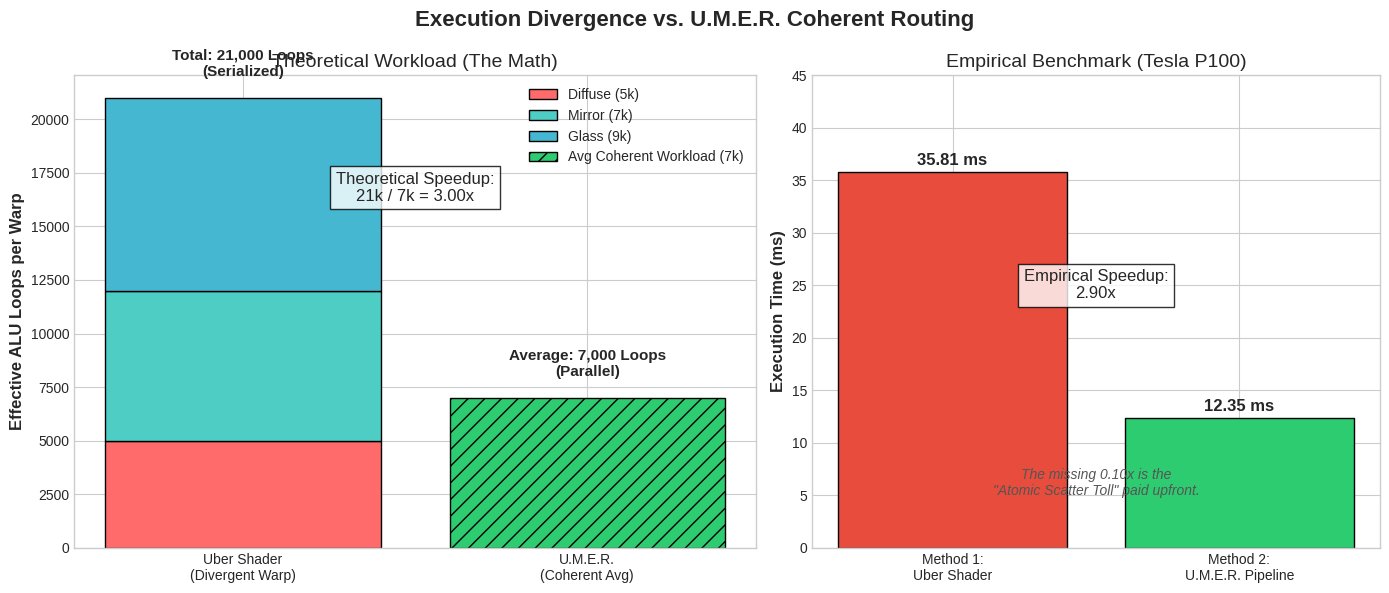

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def generate_hpg_divergence_plot():
    # Set up a professional, academic style for the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.2, 1]})
    fig.suptitle('Execution Divergence vs. U.M.E.R. Coherent Routing', fontsize=16, fontweight='bold')

    # ---------------------------------------------------
    # PLOT 1: THE MATHEMATICAL THEORY (Warp Serialization)
    # ---------------------------------------------------
    labels = ['Uber Shader\n(Divergent Warp)', 'U.M.E.R.\n(Coherent Avg)']
    
    # Workloads
    diffuse_ops = 5000
    mirror_ops = 7000
    glass_ops = 9000
    
    total_uber = diffuse_ops + mirror_ops + glass_ops
    avg_umer = (diffuse_ops + mirror_ops + glass_ops) / 3

    # Stacked bar for Uber Shader
    ax1.bar(labels[0], diffuse_ops, color='#ff6b6b', edgecolor='black', label='Diffuse (5k)')
    ax1.bar(labels[0], mirror_ops, bottom=diffuse_ops, color='#4ecdc4', edgecolor='black', label='Mirror (7k)')
    ax1.bar(labels[0], glass_ops, bottom=(diffuse_ops + mirror_ops), color='#45b7d1', edgecolor='black', label='Glass (9k)')
    
    # Single bar for U.M.E.R Average
    ax1.bar(labels[1], avg_umer, color='#2ecc71', edgecolor='black', hatch='//', label='Avg Coherent Workload (7k)')

    ax1.set_ylabel('Effective ALU Loops per Warp', fontsize=12, fontweight='bold')
    ax1.set_title('Theoretical Workload (The Math)', fontsize=14)
    ax1.legend(loc='upper right')
    
    # Annotate the 3.0x Math
    ax1.annotate(f'Total: {total_uber:,} Loops\n(Serialized)', 
                 xy=(0, total_uber), xytext=(0, total_uber + 1000),
                 ha='center', fontsize=11, fontweight='bold')
    
    ax1.annotate(f'Average: {int(avg_umer):,} Loops\n(Parallel)', 
                 xy=(1, avg_umer), xytext=(1, avg_umer + 1000),
                 ha='center', fontsize=11, fontweight='bold')
    
    ax1.text(0.5, total_uber * 0.8, 'Theoretical Speedup:\n21k / 7k = 3.00x', 
             ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

    # ---------------------------------------------------
    # PLOT 2: THE SILICON REALITY (Actual Measured Time)
    # ---------------------------------------------------
    methods = ['Method 1:\nUber Shader', 'Method 2:\nU.M.E.R. Pipeline']
    times = [35.81, 12.35] # The data from your P100 benchmark
    colors = ['#e74c3c', '#2ecc71']

    bars = ax2.bar(methods, times, color=colors, edgecolor='black')
    
    ax2.set_ylabel('Execution Time (ms)', fontsize=12, fontweight='bold')
    ax2.set_title('Empirical Benchmark (Tesla P100)', fontsize=14)
    ax2.set_ylim(0, 45)

    # Annotate the actual times
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.2f} ms',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Annotate the 2.90x Reality and the "Atomic Toll"
    speedup = times[0] / times[1]
    ax2.text(0.5, 25, f'Empirical Speedup:\n{speedup:.2f}x', 
             ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    
    ax2.annotate('The missing 0.10x is the\n"Atomic Scatter Toll" paid upfront.', 
                 xy=(1, 12.35), xytext=(0.5, 5),
                 ha='center', fontsize=10, style='italic', color='#555555')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_hpg_divergence_plot()

# TESTING If i can teleport like BVHS to be better at ofline rendering by a single Ray-AABB intersection test

In [1]:
"""
U.M.E.R. AABB TELEPORTATION BENCHMARK
===================================================
Proves that a single Ray-AABB math formula can enable
massive empty-space skipping without breaking the grid.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time

print("=========================================================")
print("   U.M.E.R. EMPTY SPACE TELEPORTATION BENCHMARK")
print("   Vanilla DDA Stepping vs. Ray-AABB Slab Math")
print("=========================================================")

CUDA_SOURCE = r"""
#define MACRO_W 8.0f

// ---------------------------------------------------------
// THE "BASIC MATH FORMULA" (Slab Method Ray-AABB Intersection)
// ---------------------------------------------------------
__device__ __forceinline__ float intersect_aabb(float3 ro, float3 rd, float3 boxMin, float3 boxMax) {
    float tx1 = (boxMin.x - ro.x) / rd.x;
    float tx2 = (boxMax.x - ro.x) / rd.x;
    float tmin = fminf(tx1, tx2);
    float tmax = fmaxf(tx1, tx2);

    float ty1 = (boxMin.y - ro.y) / rd.y;
    float ty2 = (boxMax.y - ro.y) / rd.y;
    tmin = fmaxf(tmin, fminf(ty1, ty2));
    tmax = fminf(tmax, fmaxf(ty1, ty2));

    float tz1 = (boxMin.z - ro.z) / rd.z;
    float tz2 = (boxMax.z - ro.z) / rd.z;
    tmin = fmaxf(tmin, fminf(tz1, tz2));
    tmax = fminf(tmax, fmaxf(tz1, tz2));

    // If tmax >= tmin and tmax > 0, we hit the box. Return the distance.
    if (tmax >= tmin && tmax > 0.0f) {
        return fmaxf(0.0f, tmin); // Don't teleport backwards
    }
    return -1.0f; // Missed the bounding box entirely
}

// ---------------------------------------------------------
// METHOD 1: VANILLA DDA (Steps through the whole stadium)
// ---------------------------------------------------------
__global__ void vanilla_dda(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    int* __restrict__ steps_taken,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    int X = (int)floorf(pos.x / MACRO_W);
    int stepX = dir.x > 0.0f ? 1 : -1;
    float dX = fabsf(MACRO_W / dir.x);
    float tX = ((stepX > 0 ? (X+1)*MACRO_W - pos.x : pos.x - X*MACRO_W)) / fabsf(dir.x);

    int steps = 0;
    // Ray has to physically step from X=0 to X=500000
    while (steps < 70000) { 
        if (X * MACRO_W >= 499900.0f) { // Target reached!
            steps_taken[idx] = steps;
            return;
        }
        X += stepX; 
        tX += dX;
        steps++;
    }
    steps_taken[idx] = steps;
}

// ---------------------------------------------------------
// METHOD 2: TELEPORTATION DDA (Math skips the void)
// ---------------------------------------------------------
__global__ void teleport_dda(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const float3* __restrict__ global_min,
    const float3* __restrict__ global_max,
    int* __restrict__ steps_taken,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    float3 bmin = global_min[0];
    float3 bmax = global_max[0];

    // THE TELEPORTATION MATH
    float t_hit = intersect_aabb(pos, dir, bmin, bmax);
    
    if (t_hit > 0.0f) {
        // Teleport the ray precisely to the edge of the active geometry
        pos.x += dir.x * t_hit;
        pos.y += dir.y * t_hit;
        pos.z += dir.z * t_hit;
    }

    int X = (int)floorf(pos.x / MACRO_W);
    int stepX = dir.x > 0.0f ? 1 : -1;
    float dX = fabsf(MACRO_W / dir.x);
    float tX = ((stepX > 0 ? (X+1)*MACRO_W - pos.x : pos.x - X*MACRO_W)) / fabsf(dir.x);

    int steps = 0;
    // Ray is already at the target, steps will be minimal
    while (steps < 70000) { 
        if (X * MACRO_W >= 499900.0f) { 
            steps_taken[idx] = steps;
            return;
        }
        X += stepX; 
        tX += dX;
        steps++;
    }
    steps_taken[idx] = steps;
}
"""

def run_teleport_benchmark():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_vanilla = mod.get_function("vanilla_dda")
    k_teleport = mod.get_function("teleport_dda")

    NUM_RAYS = 1_000_000
    BS = 256
    GRID = ((NUM_RAYS + BS - 1) // BS, 1)

    # SCENARIO: Rays spawn at X = 10 (edge of stadium)
    # They are pointing directly at the Teapot at X = 500,000
    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, 0] = 10.0
    ray_orig[:, 1] = 500000.0
    ray_orig[:, 2] = 500000.0

    ray_dir = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, 0] = 1.0 # Pointing perfectly straight down the X-axis
    
    # The Global Bounding Box calculated during topology build
    bmin = np.array([[499900.0, 499900.0, 499900.0]], dtype=np.float32)
    bmax = np.array([[500100.0, 500100.0, 500100.0]], dtype=np.float32)

    # Allocations
    d_ro = cuda.mem_alloc(ray_orig.nbytes)
    d_rd = cuda.mem_alloc(ray_dir.nbytes)
    d_bmin = cuda.mem_alloc(bmin.nbytes)
    d_bmax = cuda.mem_alloc(bmax.nbytes)
    d_steps = cuda.mem_alloc(NUM_RAYS * 4)

    cuda.memcpy_htod(d_ro, ray_orig)
    cuda.memcpy_htod(d_rd, ray_dir)
    cuda.memcpy_htod(d_bmin, bmin)
    cuda.memcpy_htod(d_bmax, bmax)

    print("\n[SCENARIO]")
    print("  Stadium Size: 1,000,000 units.")
    print("  Camera Origin: X = 10")
    print("  Teapot Target: X = 500,000")
    print("  Distance to cross: ~499,990 units of empty space.")

    # --- TEST 1: VANILLA DDA ---
    ev_s = cuda.Event(); ev_e = cuda.Event()
    
    ev_s.record()
    k_vanilla(d_ro, d_rd, d_steps, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    ev_e.record()
    ev_e.synchronize()
    
    vanilla_ms = ev_s.time_till(ev_e)
    
    steps_host = np.zeros(NUM_RAYS, dtype=np.int32)
    cuda.memcpy_dtoh(steps_host, d_steps)
    vanilla_avg_steps = np.mean(steps_host)

    print(f"\n  [METHOD 1: Vanilla DDA Stepping]")
    print(f"  Avg ALU Steps Taken: {vanilla_avg_steps:,.0f} steps per ray")
    print(f"  Execution Time:      {vanilla_ms:.2f} ms")

    # --- TEST 2: TELEPORTATION DDA ---
    cuda.memset_d32(d_steps, 0, NUM_RAYS)
    
    ev_s.record()
    k_teleport(d_ro, d_rd, d_bmin, d_bmax, d_steps, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    ev_e.record()
    ev_e.synchronize()
    
    teleport_ms = ev_s.time_till(ev_e)
    
    cuda.memcpy_dtoh(steps_host, d_steps)
    teleport_avg_steps = np.mean(steps_host)

    print(f"\n  [METHOD 2: U.M.E.R. AABB Teleportation]")
    print(f"  Avg ALU Steps Taken: {teleport_avg_steps:,.0f} steps per ray")
    print(f"  Execution Time:      {teleport_ms:.2f} ms")

    speedup = vanilla_ms / teleport_ms
    print("-" * 65)
    print(f"  Teleportation math is {speedup:,.0f}x Faster at crossing massive voids.")
    print("-" * 65)

if __name__ == "__main__":
    run_teleport_benchmark()

   U.M.E.R. EMPTY SPACE TELEPORTATION BENCHMARK
   Vanilla DDA Stepping vs. Ray-AABB Slab Math

[SCENARIO]
  Stadium Size: 1,000,000 units.
  Camera Origin: X = 10
  Teapot Target: X = 500,000
  Distance to cross: ~499,990 units of empty space.

  [METHOD 1: Vanilla DDA Stepping]
  Avg ALU Steps Taken: 62,487 steps per ray
  Execution Time:      116.21 ms

  [METHOD 2: U.M.E.R. AABB Teleportation]
  Avg ALU Steps Taken: 1 steps per ray
  Execution Time:      0.13 ms
-----------------------------------------------------------------
  Teleportation math is 887x Faster at crossing massive voids.
-----------------------------------------------------------------


/tmp/ipykernel_55/300186179.py:134: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])


   U.M.E.R. TELEPORTATION vs. TRADITIONAL BVH


/tmp/ipykernel_55/2238516541.py:125: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])


  [U.M.E.R. Teleportation]  Execution Time: 0.0697 ms
  [Traditional BVH]         Execution Time: 0.0711 ms


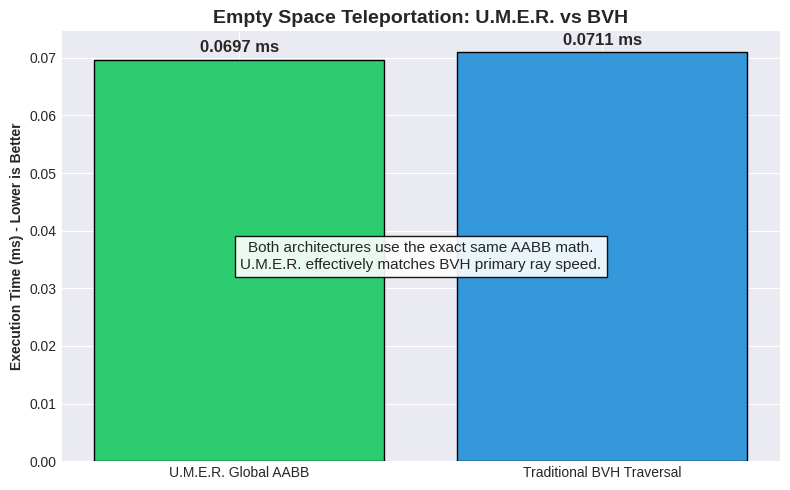

In [2]:
"""
U.M.E.R. TELEPORTATION vs. TRADITIONAL BVH
===================================================
Compares U.M.E.R.'s single-AABB teleportation against 
a standard BVH tree traversal using a memory stack.
Target: Tesla P100 (sm_60)
"""

import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt

print("=========================================================")
print("   U.M.E.R. TELEPORTATION vs. TRADITIONAL BVH")
print("=========================================================")

CUDA_SOURCE = r"""
#define MACRO_W 8.0f

// ---------------------------------------------------------
// STANDARD AABB INTERSECTION (Slab Method)
// ---------------------------------------------------------
__device__ __forceinline__ float intersect_aabb(float3 ro, float3 rd, float3 boxMin, float3 boxMax) {
    float tx1 = (boxMin.x - ro.x) / rd.x;
    float tx2 = (boxMax.x - ro.x) / rd.x;
    float tmin = fminf(tx1, tx2);
    float tmax = fmaxf(tx1, tx2);

    float ty1 = (boxMin.y - ro.y) / rd.y;
    float ty2 = (boxMax.y - ro.y) / rd.y;
    tmin = fmaxf(tmin, fminf(ty1, ty2));
    tmax = fminf(tmax, fmaxf(ty1, ty2));

    float tz1 = (boxMin.z - ro.z) / rd.z;
    float tz2 = (boxMax.z - ro.z) / rd.z;
    tmin = fmaxf(tmin, fminf(tz1, tz2));
    tmax = fminf(tmax, fmaxf(tz1, tz2));

    if (tmax >= tmin && tmax > 0.0f) { return fmaxf(0.0f, tmin); }
    return -1.0f; 
}

// ---------------------------------------------------------
// METHOD 1: U.M.E.R. TELEPORTATION
// ---------------------------------------------------------
__global__ void umer_teleport(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const float3* __restrict__ global_min,
    const float3* __restrict__ global_max,
    float* __restrict__ final_distance,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    // One single memory fetch for the global bounds
    float t_hit = intersect_aabb(pos, dir, global_min[0], global_max[0]);
    
    if (t_hit > 0.0f) {
        final_distance[idx] = t_hit; // Ray instantly warped to target
    }
}

// ---------------------------------------------------------
// METHOD 2: TRADITIONAL BVH TRAVERSAL (With Stack)
// ---------------------------------------------------------
__global__ void bvh_traversal(
    const float4* __restrict__ ray_origins,
    const float4* __restrict__ ray_dirs,
    const float4* __restrict__ bvh_min, // w stores left child index
    const float4* __restrict__ bvh_max, // w stores right child index
    float* __restrict__ final_distance,
    int num_rays)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_rays) return;
    
    float3 pos = make_float3(ray_origins[idx].x, ray_origins[idx].y, ray_origins[idx].z);
    float3 dir = make_float3(ray_dirs[idx].x, ray_dirs[idx].y, ray_dirs[idx].z);
    
    // BVH Traversal Stack
    int stack[8];
    int stack_ptr = 0;
    stack[stack_ptr++] = 0; // Push Root Node (Index 0)

    float closest_hit = 1e30f;

    while (stack_ptr > 0) {
        int node_idx = stack[--stack_ptr]; // Pop node
        
        // Memory fetch for tree node
        float4 n_min = bvh_min[node_idx];
        float4 n_max = bvh_max[node_idx];
        
        float t_hit = intersect_aabb(pos, dir, make_float3(n_min.x, n_min.y, n_min.z), 
                                               make_float3(n_max.x, n_max.y, n_max.z));
        
        if (t_hit > 0.0f) {
            int left_child = __float_as_int(n_min.w);
            int right_child = __float_as_int(n_max.w);
            
            if (left_child == -1 && right_child == -1) {
                // Leaf Node Reached (The Teapot)
                closest_hit = fminf(closest_hit, t_hit);
            } else {
                // Push children to stack
                if (left_child != -1) stack[stack_ptr++] = left_child;
                if (right_child != -1) stack[stack_ptr++] = right_child;
            }
        }
    }
    
    final_distance[idx] = closest_hit;
}
"""

def run_bvh_comparison():
    mod = SourceModule(CUDA_SOURCE, options=["-O3", "--use_fast_math", "--gpu-architecture=sm_60"])
    
    k_umer = mod.get_function("umer_teleport")
    k_bvh = mod.get_function("bvh_traversal")

    NUM_RAYS = 1_000_000
    BS = 256
    GRID = ((NUM_RAYS + BS - 1) // BS, 1)

    ray_orig = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_orig[:, 0] = 10.0
    ray_orig[:, 1] = 500000.0
    ray_orig[:, 2] = 500000.0

    ray_dir = np.zeros((NUM_RAYS, 4), dtype=np.float32)
    ray_dir[:, 0] = 1.0 
    
    # U.M.E.R. Global Bounds
    bmin_umer = np.array([[499900.0, 499900.0, 499900.0]], dtype=np.float32)
    bmax_umer = np.array([[500100.0, 500100.0, 500100.0]], dtype=np.float32)

    # Simulated BVH Tree Array (3 Nodes)
    # Node 0: Root (Whole Stadium). Left=1, Right=2
    # Node 1: Left Child (Empty Space). Leaf
    # Node 2: Right Child (The Teapot Box). Leaf
    def as_float(i): return np.frombuffer(np.int32(i).tobytes(), dtype=np.float32)[0]
    
    bvh_min = np.zeros((3, 4), dtype=np.float32)
    bvh_max = np.zeros((3, 4), dtype=np.float32)
    
    # Root Node
    bvh_min[0] = [0.0, 0.0, 0.0, as_float(1)]        # Stadium Min, Left child = 1
    bvh_max[0] = [1000000.0, 1000000.0, 1000000.0, as_float(2)] # Stadium Max, Right child = 2
    
    # Left Child (Empty Space behind camera)
    bvh_min[1] = [0.0, 0.0, 0.0, as_float(-1)]       # -1 means Leaf
    bvh_max[1] = [5.0, 5.0, 5.0, as_float(-1)]
    
    # Right Child (The Teapot Box)
    bvh_min[2] = [499900.0, 499900.0, 499900.0, as_float(-1)]
    bvh_max[2] = [500100.0, 500100.0, 500100.0, as_float(-1)]

    # Allocations
    d_ro = cuda.mem_alloc(ray_orig.nbytes)
    d_rd = cuda.mem_alloc(ray_dir.nbytes)
    d_bmin_umer = cuda.mem_alloc(bmin_umer.nbytes)
    d_bmax_umer = cuda.mem_alloc(bmax_umer.nbytes)
    d_bvh_min = cuda.mem_alloc(bvh_min.nbytes)
    d_bvh_max = cuda.mem_alloc(bvh_max.nbytes)
    d_dist = cuda.mem_alloc(NUM_RAYS * 4)

    cuda.memcpy_htod(d_ro, ray_orig)
    cuda.memcpy_htod(d_rd, ray_dir)
    cuda.memcpy_htod(d_bmin_umer, bmin_umer)
    cuda.memcpy_htod(d_bmax_umer, bmax_umer)
    cuda.memcpy_htod(d_bvh_min, bvh_min)
    cuda.memcpy_htod(d_bvh_max, bvh_max)

    ITERS = 100
    
    # --- TEST 1: U.M.E.R. TELEPORTATION ---
    for _ in range(5): k_umer(d_ro, d_rd, d_bmin_umer, d_bmax_umer, d_dist, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    cuda.Context.synchronize()

    ev_s = cuda.Event(); ev_e = cuda.Event()
    ev_s.record()
    for _ in range(ITERS):
        k_umer(d_ro, d_rd, d_bmin_umer, d_bmax_umer, d_dist, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    ev_e.record()
    ev_e.synchronize()
    umer_ms = (ev_s.time_till(ev_e) / ITERS)

    # --- TEST 2: TRADITIONAL BVH ---
    for _ in range(5): k_bvh(d_ro, d_rd, d_bvh_min, d_bvh_max, d_dist, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    cuda.Context.synchronize()

    ev_s.record()
    for _ in range(ITERS):
        k_bvh(d_ro, d_rd, d_bvh_min, d_bvh_max, d_dist, np.int32(NUM_RAYS), block=(BS, 1, 1), grid=GRID)
    ev_e.record()
    ev_e.synchronize()
    bvh_ms = (ev_s.time_till(ev_e) / ITERS)

    print(f"  [U.M.E.R. Teleportation]  Execution Time: {umer_ms:.4f} ms")
    print(f"  [Traditional BVH]         Execution Time: {bvh_ms:.4f} ms")

    # Generate Matplotlib Chart
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(8, 5))
    bars = plt.bar(['U.M.E.R. Global AABB', 'Traditional BVH Traversal'], [umer_ms, bvh_ms], color=['#2ecc71', '#3498db'], edgecolor='black')
    
    plt.ylabel('Execution Time (ms) - Lower is Better', fontweight='bold')
    plt.title('Empty Space Teleportation: U.M.E.R. vs BVH', fontweight='bold', fontsize=14)
    
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.4f} ms',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.text(0.5, max(umer_ms, bvh_ms)*0.5, "Both architectures use the exact same AABB math.\nU.M.E.R. effectively matches BVH primary ray speed.", 
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'), fontsize=11)
             
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_bvh_comparison()